In [276]:
import h5py
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.cm import ScalarMappable

from sklearn.linear_model import Ridge, LinearRegression, SGDRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF
import time
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from pathlib import Path


In [277]:

# Configuration
TASK_MODE = 'sample'
FRAMEWORK_NAME = 'Framework2'                  # 'parameter_set' uses Framework1 comparison; 'sample' uses Framework2 u0/coeff -> trajectory
FRAMEWORK_DIR_BY_TASK = {                    # maps each task mode to the framework folder that stores its PDE datasets
    'parameter_set': 'Framework1',
    'sample': 'Framework2',
}
BASE_DIR = Path(FRAMEWORK_DIR_BY_TASK[TASK_MODE])  # framework folder selected automatically from TASK_MODE
#BASE_DIR = Path(FRAMEWORK_NAME)
RESULTS_DIR = BASE_DIR #Path('resultsFramework2onFramework1') #BASE_DIR                       # folder where result CSV files are written

PDE_NAME = 'Param_wave'                # PDE folder to run; Framework1 uses Parametric_Wave, Framework2 uses Param_wave
DATA_SUBDIR = 'dataset_simple'               # subfolder inside the PDE folder that contains HDF5 files
DATA_FILENAME = 'solutions.h5'               # in-distribution HDF5 filename
OOD_GLOB = 'ood*.h5'                         # evaluate every matching OOD HDF5 file inside DATA_SUBDIR
USE_OOD = True                               # if False, skip all OOD loading/evaluation/visualization

ICS_PER_PARAM = 20                           # number of initial conditions generated for each coefficient/parameter set; parameter_set mode only
TRAIN_FRACTION = 0.8                         # fraction of parameter sets/samples used for training
TRAIN_SIZE = 10000 if TASK_MODE == 'sample' else None  # Framework2 previously used 10000 samples; Framework1 uses TRAIN_FRACTION over parameter sets

PDE_DIR = BASE_DIR / PDE_NAME                # resolved PDE folder
DATA_PATH = PDE_DIR / DATA_SUBDIR / DATA_FILENAME  # in-distribution HDF5 path
OOD_PATHS = sorted((PDE_DIR / DATA_SUBDIR).glob(OOD_GLOB))  # all OOD HDF5 paths for this PDE
DATA_KEY = 'data'                            # HDF5 dataset key for solution arrays, shape (N, T, X, C)
COEFF_KEY = 'coeffs'                         # HDF5 dataset key for PDE coefficient/parameter arrays
INPUT_TIME_INDEX = 0                         # time index used as the input initial condition u(t_index, x) in sample mode
CHANNEL_INDEX = 0                            # solution channel/variable index; 0 is the only valid choice if C=1

ALPHA = 1e-10                                # GPR nugget/noise regularization added to the kernel diagonal

VANILLA_RBF_LENGTH_SCALE = 10                                      # vanilla baseline on initial condition u0 -> trajectory
VANILLA_MATERN_LENGTH_SCALE = 100                                   # vanilla baseline on initial condition u0 -> trajectory
VANILLA_MATERN_NU = 3/2                                             # smoothness parameter for the vanilla Matern kernel

PRODUCT_COEF_LENGTH_SCALE = 1                # length scale for the coefficient Matern kernel in the product model; sample mode only
PRODUCT_COEF_NU = 5/2                        # smoothness parameter for the coefficient Matern kernel; sample mode only
PRODUCT_STATE_LENGTH_SCALE = 1000             # length scale for the initial-condition Matern kernel in the product model; sample mode only
PRODUCT_STATE_NU = 5/2                       # smoothness parameter for the initial-condition Matern kernel; sample mode only

PRODUCT_RBF_COEF_LENGTH_SCALE = 1            # length scale for the coefficient RBF kernel in the product RBF model; sample mode only
PRODUCT_RBF_STATE_LENGTH_SCALE = 1000         # length scale for the initial-condition RBF kernel in the product RBF model; sample mode only

FRAMEWORK1_RBF_LENGTH_SCALE = 10             # Framework1 method RBF length scale on coefficients W -> {G_W: U -> V}
FRAMEWORK1_MATERN_LENGTH_SCALE = 1            # Framework1 method Matern length scale on coefficients W -> {G_W: U -> V}
FRAMEWORK1_MATERN_NU = 5/2                    # Framework1 method Matern smoothness on coefficients                   # Framework1 method Matern smoothness on coefficients

USE_PCA = False                              # master switch for PCA preprocessing
USE_X_PCA = True                             # if USE_PCA=True, reduce model inputs; in parameter_set mode these are coefficients
USE_COEF_PCA = True                          # if USE_PCA=True, reduce coefficient vectors for product kernels; sample mode only
USE_Y_PCA = True                             # if USE_PCA=True, reduce the output trajectory before learning
Y_PCA_BY_TIME = True                         # if True, fit one output PCA per time slice; in parameter_set mode each time slice contains all ICs and x-points

N_X_PCA = 5                                  # model-input PCA dimension
N_COEF_PCA = 4                               # coefficient PCA dimension for product kernels; sample mode only
N_Y_PCA = 5                                  # output PCA dimension; if Y_PCA_BY_TIME=True, this is per time slice

VIS_IDX = 0                                  # parameter-set/sample index used in the final visualization cell
VIS_IC_IDX = 0                               # initial-condition index to visualize when TASK_MODE='parameter_set'
VIS_PLOT_OOD = False                         # if True, visualize OOD predictions; otherwise visualize test predictions
VIS_OOD_FILENAME = 'ood_par_init.h5'                       # choose an OOD file for visualization, or use the first matching file
UQ_STD_MULTIPLIER = 1.0                       # plot prediction plus/minus this many pointwise standard deviations
UQ_EXPORT_DAT = False                           # export final-time UQ curves for PGFPlots/TikZ
UQ_EXPORT_DIR = Path('uq_exports')              # output folder for final-time .dat files
UQ_EXPORT_IMAGES = True                         # save clean 2D and 3D Matplotlib UQ images per method
UQ_IMAGE_DIR = Path('uq_images')                 # output folder for clean Matplotlib images
UQ_IMAGE_DPI = 600                               # resolution for exported UQ .png images
MATPLOTLIB_CMAP = 'viridis'                      # colormap for trajectory fields and UQ mean surfaces
ERROR_CMAP = 'coolwarm'                          # diverging colormap for signed prediction errors
UQ_PLOT_CONFIDENCE_SURFACES = True               # draw lower/upper confidence surfaces in 3D UQ plots
UQ_CONFIDENCE_SURFACE_COLOR = 'tab:orange'        # color for 3D lower/upper confidence surfaces
UQ_CONFIDENCE_SURFACE_ALPHA = 0.18               # opacity for 3D lower/upper confidence surfaces
UQ_SURFACE_ELEV = 25                          # vertical camera angle for the 3D UQ surfaces
UQ_SURFACE_AZIM = -135                        # horizontal camera angle; this view places visible x=0 and t=0 together


In [278]:

# Load data and create train/test/OOD splits
if TASK_MODE not in {'parameter_set', 'sample'}:
    raise ValueError("TASK_MODE must be either 'parameter_set' or 'sample'.")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'Could not find {DATA_PATH}. Check TASK_MODE={TASK_MODE!r}, BASE_DIR={BASE_DIR}, and PDE_NAME={PDE_NAME!r}.'
    )
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

with h5py.File(DATA_PATH, 'r') as f:
    dataset = f[DATA_KEY][:]
    coef = f[COEFF_KEY][:]

print('PDE:', PDE_NAME)
print('Task mode:', TASK_MODE)
print('Data path:', DATA_PATH)
print('Dataset shape:', dataset.shape)
print('Coefficient shape:', coef.shape)

if TASK_MODE == 'parameter_set':
    n_param_sets = dataset.shape[0] // ICS_PER_PARAM
    n_usable_samples = n_param_sets * ICS_PER_PARAM
    if n_usable_samples != dataset.shape[0]:
        print(f'Using first {n_usable_samples} samples so data is divisible by ICS_PER_PARAM={ICS_PER_PARAM}.')

    dataset_used = dataset[:n_usable_samples]
    coef_used = coef[:n_usable_samples]
    coef_by_param = coef_used[::ICS_PER_PARAM]
    Y_by_param = dataset_used[:, :, :, CHANNEL_INDEX].reshape(
        n_param_sets, ICS_PER_PARAM, dataset.shape[1], dataset.shape[2]
    )

    train_param_count = TRAIN_SIZE if TRAIN_SIZE is not None else int(TRAIN_FRACTION * n_param_sets)
    if train_param_count <= 0 or train_param_count >= n_param_sets:
        raise ValueError(f'train_param_count={train_param_count} must be between 1 and {n_param_sets - 1}.')
    train_sample_count = train_param_count * ICS_PER_PARAM

    # Vanilla baseline: initial condition -> trajectory, one row per IC trajectory.
    X_train = dataset_used[:train_sample_count, INPUT_TIME_INDEX, :, CHANNEL_INDEX]
    Y_train = dataset_used[:train_sample_count, :, :, CHANNEL_INDEX]
    X_test = dataset_used[train_sample_count:, INPUT_TIME_INDEX, :, CHANNEL_INDEX]
    Y_test = dataset_used[train_sample_count:, :, :, CHANNEL_INDEX]
    coef_train = coef_used[:train_sample_count]
    coef_test = coef_used[train_sample_count:]

    # Framework1 method: coefficients -> all fixed-IC trajectories for that coefficient set.
    fw1_X_train = coef_by_param[:train_param_count]
    fw1_Y_train = Y_by_param[:train_param_count]
    fw1_X_test = coef_by_param[train_param_count:]
    fw1_Y_test = Y_by_param[train_param_count:]

elif TASK_MODE == 'sample':
    train_count = TRAIN_SIZE if TRAIN_SIZE is not None else int(TRAIN_FRACTION * dataset.shape[0])
    testSize = dataset.shape[0] - train_count
    if testSize <= 0:
        raise ValueError(f'train_count={train_count} leaves no test samples for dataset with {dataset.shape[0]} samples.')

    X_train = dataset[:train_count, INPUT_TIME_INDEX, :, CHANNEL_INDEX]
    Y_train = dataset[:train_count, :, :, CHANNEL_INDEX]
    X_test = dataset[train_count:, INPUT_TIME_INDEX, :, CHANNEL_INDEX]
    Y_test = dataset[train_count:, :, :, CHANNEL_INDEX]
    coef_train = coef[:train_count]
    coef_test = coef[train_count:]

    fw1_X_train = fw1_Y_train = fw1_X_test = fw1_Y_test = None
else:
    raise ValueError("TASK_MODE must be either 'parameter_set' or 'sample'.")

def make_ood_case(ood_path):
    with h5py.File(ood_path, 'r') as f_ood:
        dataset_ood = f_ood[DATA_KEY][:]
        coef_ood_raw = f_ood[COEFF_KEY][:]

    case = {'path': Path(ood_path), 'ood_filename': Path(ood_path).name, 'dataset': dataset_ood}
    if TASK_MODE == 'parameter_set':
        n_ood_param_sets = dataset_ood.shape[0] // ICS_PER_PARAM
        n_ood_usable_samples = n_ood_param_sets * ICS_PER_PARAM
        dataset_ood_used = dataset_ood[:n_ood_usable_samples]
        coef_ood_used = coef_ood_raw[:n_ood_usable_samples]
        case['fw1_X'] = coef_ood_used[::ICS_PER_PARAM]
        case['fw1_Y'] = dataset_ood_used[:, :, :, CHANNEL_INDEX].reshape(
            n_ood_param_sets, ICS_PER_PARAM, dataset_ood.shape[1], dataset_ood.shape[2]
        )
        case['X'] = dataset_ood_used[:, INPUT_TIME_INDEX, :, CHANNEL_INDEX]
        case['Y'] = dataset_ood_used[:, :, :, CHANNEL_INDEX]
        case['coef'] = coef_ood_used
    else:
        case['X'] = dataset_ood[:, INPUT_TIME_INDEX, :, CHANNEL_INDEX]
        case['Y'] = dataset_ood[:, :, :, CHANNEL_INDEX]
        case['coef'] = coef_ood_raw
        case['fw1_X'] = case['fw1_Y'] = None
    return case


OOD_CASES = [make_ood_case(ood_path) for ood_path in OOD_PATHS] if USE_OOD else []
HAS_OOD = bool(OOD_CASES)
OOD_VIS_CASE = next(
    (case for case in OOD_CASES if case['ood_filename'] == VIS_OOD_FILENAME),
    OOD_CASES[0] if HAS_OOD else None,
)

if HAS_OOD:
    # Existing visualization aliases point at one selected OOD file.
    dataset_ood = OOD_VIS_CASE['dataset']
    X_ood = OOD_VIS_CASE['X']
    Y_ood = OOD_VIS_CASE['Y']
    coef_ood = OOD_VIS_CASE['coef']
    fw1_X_ood = OOD_VIS_CASE['fw1_X']
    fw1_Y_ood = OOD_VIS_CASE['fw1_Y']
    print('OOD files:', [case['ood_filename'] for case in OOD_CASES])
    print('OOD visualization file:', OOD_VIS_CASE['ood_filename'])
else:
    dataset_ood = None
    coef_ood = None
    X_ood = None
    Y_ood = None
    fw1_X_ood = fw1_Y_ood = None
    if USE_OOD:
        print(f'No OOD files matched {OOD_GLOB!r} in {PDE_DIR / DATA_SUBDIR}. Skipping OOD evaluation.')
    else:
        print('OOD evaluation disabled.')

print('Vanilla train shapes:', X_train.shape, coef_train.shape, Y_train.shape)
print('Vanilla test shapes:', X_test.shape, coef_test.shape, Y_test.shape)
if TASK_MODE == 'parameter_set':
    print('Framework1 train shapes:', fw1_X_train.shape, fw1_Y_train.shape)
    print('Framework1 test shapes:', fw1_X_test.shape, fw1_Y_test.shape)
if HAS_OOD:
    for ood_case in OOD_CASES:
        print(f"Vanilla OOD shapes [{ood_case['ood_filename']}]:", ood_case['X'].shape, ood_case['coef'].shape, ood_case['Y'].shape)
        if TASK_MODE == 'parameter_set':
            print(f"Framework1 OOD shapes [{ood_case['ood_filename']}]:", ood_case['fw1_X'].shape, ood_case['fw1_Y'].shape)


PDE: Param_wave
Task mode: sample
Data path: Framework2/Param_wave/dataset_simple/solutions.h5
Dataset shape: (14000, 64, 128, 1)
Coefficient shape: (14000, 64)
OOD files: ['ood_init.h5', 'ood_par_init.h5', 'ood_par_kernel.h5', 'ood_par_scale.h5', 'ood_par_var.h5']
OOD visualization file: ood_par_init.h5
Vanilla train shapes: (10000, 128) (10000, 64) (10000, 64, 128)
Vanilla test shapes: (4000, 128) (4000, 64) (4000, 64, 128)
Vanilla OOD shapes [ood_init.h5]: (4000, 128) (4000, 64) (4000, 64, 128)
Vanilla OOD shapes [ood_par_init.h5]: (4000, 128) (4000, 64) (4000, 64, 128)
Vanilla OOD shapes [ood_par_kernel.h5]: (4000, 128) (4000, 64) (4000, 64, 128)
Vanilla OOD shapes [ood_par_scale.h5]: (4000, 128) (4000, 64) (4000, 64, 128)
Vanilla OOD shapes [ood_par_var.h5]: (4000, 128) (4000, 64) (4000, 64, 128)


In [279]:

# Optional PCA preprocessing
Y_TRAIN_SHAPE = Y_train.shape[1:]

Y_train_flat = Y_train.reshape(Y_train.shape[0], -1)
Y_test_flat = Y_test.reshape(Y_test.shape[0], -1)
Y_ood_flat = Y_ood.reshape(Y_ood.shape[0], -1) if HAS_OOD else None

# Vanilla/sample input PCA: u0 -> trajectory.
if USE_PCA and USE_X_PCA:
    n_x_components = min(N_X_PCA, X_train.shape[0], X_train.shape[1])
    x_pca = PCA(n_components=n_x_components)
    X_train_model = x_pca.fit_transform(X_train)
    X_test_model = x_pca.transform(X_test)
    X_ood_model = x_pca.transform(X_ood) if HAS_OOD else None
    for ood_case in OOD_CASES:
        ood_case['X_model'] = x_pca.transform(ood_case['X'])
else:
    x_pca = None
    X_train_model = X_train
    X_test_model = X_test
    X_ood_model = X_ood if HAS_OOD else None
    for ood_case in OOD_CASES:
        ood_case['X_model'] = ood_case['X']

# Coefficient PCA for Framework2 product kernels only.
if USE_PCA and USE_COEF_PCA and TASK_MODE == 'sample':
    n_coef_components = min(N_COEF_PCA, coef_train.shape[0], coef_train.shape[1])
    coef_pca = PCA(n_components=n_coef_components)
    coef_train_model = coef_pca.fit_transform(coef_train)
    coef_test_model = coef_pca.transform(coef_test)
    coef_ood_model = coef_pca.transform(coef_ood) if HAS_OOD else None
    for ood_case in OOD_CASES:
        ood_case['coef_model'] = coef_pca.transform(ood_case['coef'])
else:
    coef_pca = None
    coef_train_model = coef_train
    coef_test_model = coef_test
    coef_ood_model = coef_ood if HAS_OOD else None
    for ood_case in OOD_CASES:
        ood_case['coef_model'] = ood_case['coef']

def outputs_by_time(Y):
    return np.moveaxis(Y, -2, 1)

def outputs_from_time(Y_by_time):
    return np.moveaxis(Y_by_time, 1, -2)

# Vanilla/sample output PCA: one PCA per time step on spatial functions.
if USE_PCA and USE_Y_PCA and Y_PCA_BY_TIME:
    y_pcas = []
    y_component_slices = []
    y_train_parts = []
    Y_train_time = outputs_by_time(Y_train)
    per_time_shape = Y_train_time.shape[2:]
    start = 0
    for t in range(Y_train_time.shape[1]):
        Y_train_t = Y_train_time[:, t].reshape(Y_train.shape[0], -1)
        n_y_components = min(N_Y_PCA, Y_train_t.shape[0], Y_train_t.shape[1])
        pca_t = PCA(n_components=n_y_components)
        y_train_t = pca_t.fit_transform(Y_train_t)
        y_pcas.append(pca_t)
        y_train_parts.append(y_train_t)
        stop = start + n_y_components
        y_component_slices.append(slice(start, stop))
        start = stop
    Y_train_model = np.hstack(y_train_parts)

    def decode_prediction(prediction):
        prediction = np.asarray(prediction)
        decoded_times = []
        for pca_t, sl in zip(y_pcas, y_component_slices):
            decoded_t = pca_t.inverse_transform(prediction[:, sl]).reshape((prediction.shape[0],) + per_time_shape)
            decoded_times.append(decoded_t)
        return outputs_from_time(np.stack(decoded_times, axis=1))

    def decode_std(std):
        std = np.asarray(std)
        if std.ndim == 1:
            return std
        decoded_times = []
        for pca_t, sl in zip(y_pcas, y_component_slices):
            decoded_var_t = (std[:, sl]**2) @ (pca_t.components_**2)
            decoded_t = np.sqrt(np.maximum(decoded_var_t, 0.0)).reshape((std.shape[0],) + per_time_shape)
            decoded_times.append(decoded_t)
        return outputs_from_time(np.stack(decoded_times, axis=1))
elif USE_PCA and USE_Y_PCA:
    n_y_components = min(N_Y_PCA, Y_train_flat.shape[0], Y_train_flat.shape[1])
    y_pca = PCA(n_components=n_y_components)
    Y_train_model = y_pca.fit_transform(Y_train_flat)

    def decode_prediction(prediction):
        prediction = np.asarray(prediction)
        decoded = y_pca.inverse_transform(prediction)
        return decoded.reshape((-1,) + Y_TRAIN_SHAPE)

    def decode_std(std):
        std = np.asarray(std)
        if std.ndim == 1:
            return std
        decoded_var = (std**2) @ (y_pca.components_**2)
        return np.sqrt(np.maximum(decoded_var, 0.0)).reshape((-1,) + Y_TRAIN_SHAPE)
else:
    y_pca = None
    y_pcas = []
    Y_train_model = Y_train_flat

    def decode_prediction(prediction):
        return np.asarray(prediction).reshape((-1,) + Y_TRAIN_SHAPE)

    def decode_std(std):
        return std

# Framework1 method PCA: coefficients -> all fixed-IC trajectories.
# For output PCA by time, the same PCA basis is shared by every IC at that time step.
if TASK_MODE == 'parameter_set':
    if USE_PCA and USE_X_PCA:
        n_fw1_x_components = min(N_X_PCA, fw1_X_train.shape[0], fw1_X_train.shape[1])
        fw1_x_pca = PCA(n_components=n_fw1_x_components)
        fw1_X_train_model = fw1_x_pca.fit_transform(fw1_X_train)
        fw1_X_test_model = fw1_x_pca.transform(fw1_X_test)
        fw1_X_ood_model = fw1_x_pca.transform(fw1_X_ood) if HAS_OOD else None
        for ood_case in OOD_CASES:
            ood_case['fw1_X_model'] = fw1_x_pca.transform(ood_case['fw1_X'])
    else:
        fw1_x_pca = None
        fw1_X_train_model = fw1_X_train
        fw1_X_test_model = fw1_X_test
        fw1_X_ood_model = fw1_X_ood if HAS_OOD else None
        for ood_case in OOD_CASES:
            ood_case['fw1_X_model'] = ood_case['fw1_X']

    fw1_Y_TRAIN_SHAPE = fw1_Y_train.shape[1:]
    fw1_Y_train_flat = fw1_Y_train.reshape(fw1_Y_train.shape[0], -1)

    if USE_PCA and USE_Y_PCA and Y_PCA_BY_TIME:
        fw1_y_pcas = []
        fw1_y_component_slices = []
        fw1_y_train_parts = []
        fw1_n_ic = fw1_Y_train.shape[1]
        fw1_n_t = fw1_Y_train.shape[2]
        fw1_n_x = fw1_Y_train.shape[3]
        start = 0
        for t in range(fw1_n_t):
            # Shape is (n_params * n_ics, n_x): one shared spatial PCA for all ICs at this time.
            Y_t = fw1_Y_train[:, :, t, :].reshape(fw1_Y_train.shape[0] * fw1_n_ic, fw1_n_x)
            n_y_components = min(N_Y_PCA, Y_t.shape[0], Y_t.shape[1])
            pca_t = PCA(n_components=n_y_components)
            Y_t_model = pca_t.fit_transform(Y_t).reshape(fw1_Y_train.shape[0], fw1_n_ic * n_y_components)
            fw1_y_pcas.append(pca_t)
            fw1_y_train_parts.append(Y_t_model)
            stop = start + fw1_n_ic * n_y_components
            fw1_y_component_slices.append((slice(start, stop), n_y_components))
            start = stop
        fw1_Y_train_model = np.hstack(fw1_y_train_parts)

        def decode_fw1_prediction(prediction):
            prediction = np.asarray(prediction)
            decoded_times = []
            for pca_t, (sl, n_components) in zip(fw1_y_pcas, fw1_y_component_slices):
                coeffs_t = prediction[:, sl].reshape(prediction.shape[0] * fw1_n_ic, n_components)
                decoded_t = pca_t.inverse_transform(coeffs_t).reshape(prediction.shape[0], fw1_n_ic, fw1_n_x)
                decoded_times.append(decoded_t)
            return np.stack(decoded_times, axis=2)

        def decode_fw1_std(std):
            std = np.asarray(std)
            if std.ndim == 1:
                return std
            decoded_times = []
            for pca_t, (sl, n_components) in zip(fw1_y_pcas, fw1_y_component_slices):
                std_t = std[:, sl].reshape(std.shape[0] * fw1_n_ic, n_components)
                decoded_var_t = (std_t**2) @ (pca_t.components_**2)
                decoded_t = np.sqrt(np.maximum(decoded_var_t, 0.0)).reshape(std.shape[0], fw1_n_ic, fw1_n_x)
                decoded_times.append(decoded_t)
            return np.stack(decoded_times, axis=2)
    elif USE_PCA and USE_Y_PCA:
        n_fw1_y_components = min(N_Y_PCA, fw1_Y_train_flat.shape[0], fw1_Y_train_flat.shape[1])
        fw1_y_pca = PCA(n_components=n_fw1_y_components)
        fw1_Y_train_model = fw1_y_pca.fit_transform(fw1_Y_train_flat)

        def decode_fw1_prediction(prediction):
            prediction = np.asarray(prediction)
            return fw1_y_pca.inverse_transform(prediction).reshape((-1,) + fw1_Y_TRAIN_SHAPE)

        def decode_fw1_std(std):
            std = np.asarray(std)
            if std.ndim == 1:
                return std
            decoded_var = (std**2) @ (fw1_y_pca.components_**2)
            return np.sqrt(np.maximum(decoded_var, 0.0)).reshape((-1,) + fw1_Y_TRAIN_SHAPE)
    else:
        fw1_y_pca = None
        fw1_y_pcas = []
        fw1_Y_train_model = fw1_Y_train_flat

        def decode_fw1_prediction(prediction):
            return np.asarray(prediction).reshape((-1,) + fw1_Y_TRAIN_SHAPE)

        def decode_fw1_std(std):
            return std
else:
    fw1_x_pca = None
    fw1_X_train_model = fw1_X_test_model = fw1_X_ood_model = None
    fw1_Y_train_model = None

pca_tag = (
    f'pca_x{X_train_model.shape[1]}_c{coef_train_model.shape[1]}_y{Y_train_model.shape[1]}'
    if USE_PCA else 'no_pca'
)
if USE_PCA and TASK_MODE == 'parameter_set':
    pca_tag = f'{pca_tag}_fw1x{fw1_X_train_model.shape[1]}_fw1y{fw1_Y_train_model.shape[1]}'
pde_tag = str(PDE_NAME).replace('/', '_').replace(' ', '_')
task_tag = str(TASK_MODE).replace('/', '_').replace(' ', '_')
results_filename = f'results_{pde_tag}_{task_tag}_{pca_tag}_all_ood.csv'
results_path = RESULTS_DIR / results_filename

print('PCA enabled:', USE_PCA)
print('X/input PCA enabled:', USE_PCA and USE_X_PCA)
print('Coefficient PCA enabled:', USE_PCA and USE_COEF_PCA and TASK_MODE == 'sample')
print('Y PCA enabled:', USE_PCA and USE_Y_PCA)
print('Y PCA by time:', USE_PCA and USE_Y_PCA and Y_PCA_BY_TIME)
print('Vanilla X model shapes:', X_train_model.shape, X_test_model.shape, X_ood_model.shape if HAS_OOD else None)
print('Coefficient model shapes:', coef_train_model.shape, coef_test_model.shape, coef_ood_model.shape if HAS_OOD else None)
print('Vanilla Y train model shape:', Y_train_model.shape)
if TASK_MODE == 'parameter_set':
    print('Framework1 X model shapes:', fw1_X_train_model.shape, fw1_X_test_model.shape, fw1_X_ood_model.shape if HAS_OOD else None)
    print('Framework1 Y train model shape:', fw1_Y_train_model.shape)
print('Results file:', results_path)

if USE_PCA and USE_X_PCA:
    x_recon = x_pca.inverse_transform(X_train_model)
    x_recon_error = np.linalg.norm(x_recon - X_train) / np.linalg.norm(X_train)
    print('Vanilla X/input PCA explained variance:', np.sum(x_pca.explained_variance_ratio_))
    print('Vanilla X/input train reconstruction relative error:', x_recon_error)

if USE_PCA and USE_COEF_PCA and TASK_MODE == 'sample':
    coef_recon = coef_pca.inverse_transform(coef_train_model)
    coef_recon_error = np.linalg.norm(coef_recon - coef_train) / np.linalg.norm(coef_train)
    print('Coefficient PCA explained variance:', np.sum(coef_pca.explained_variance_ratio_))
    print('Coefficient train reconstruction relative error:', coef_recon_error)

if USE_PCA and USE_Y_PCA:
    y_recon = decode_prediction(Y_train_model)
    y_recon_error = np.linalg.norm(y_recon - Y_train) / np.linalg.norm(Y_train)
    if Y_PCA_BY_TIME:
        y_explained = np.mean([np.sum(pca_t.explained_variance_ratio_) for pca_t in y_pcas])
        print('Vanilla mean per-time Y PCA explained variance:', y_explained)
    else:
        print('Vanilla Y PCA explained variance:', np.sum(y_pca.explained_variance_ratio_))
    print('Vanilla Y train reconstruction relative error:', y_recon_error)

if USE_PCA and TASK_MODE == 'parameter_set':
    if USE_X_PCA:
        fw1_x_recon = fw1_x_pca.inverse_transform(fw1_X_train_model)
        fw1_x_recon_error = np.linalg.norm(fw1_x_recon - fw1_X_train) / np.linalg.norm(fw1_X_train)
        print('Framework1 X/coefficient PCA explained variance:', np.sum(fw1_x_pca.explained_variance_ratio_))
        print('Framework1 X/coefficient reconstruction relative error:', fw1_x_recon_error)
    if USE_Y_PCA:
        fw1_y_recon = decode_fw1_prediction(fw1_Y_train_model)
        fw1_y_recon_error = np.linalg.norm(fw1_y_recon - fw1_Y_train) / np.linalg.norm(fw1_Y_train)
        if Y_PCA_BY_TIME:
            fw1_y_explained = np.mean([np.sum(pca_t.explained_variance_ratio_) for pca_t in fw1_y_pcas])
            print('Framework1 mean per-time shared-IC Y PCA explained variance:', fw1_y_explained)
        else:
            print('Framework1 Y PCA explained variance:', np.sum(fw1_y_pca.explained_variance_ratio_))
        print('Framework1 Y train reconstruction relative error:', fw1_y_recon_error)


PCA enabled: False
X/input PCA enabled: False
Coefficient PCA enabled: False
Y PCA enabled: False
Y PCA by time: False
Vanilla X model shapes: (10000, 128) (4000, 128) (4000, 128)
Coefficient model shapes: (10000, 64) (4000, 64) (4000, 64)
Vanilla Y train model shape: (10000, 8192)
Results file: Framework2/results_Param_wave_sample_no_pca_all_ood.csv


# Vanilla Kernel

In [280]:

results = []


def relative_errors(pred, target):
    pred = np.asarray(pred)
    target = np.asarray(target)
    if TASK_MODE == 'parameter_set' and pred.ndim == 4:
        # Match the original Framework1 notebooks: report one error per IC trajectory,
        # even though the model predicts all ICs for a coefficient set together.
        pred = pred.reshape(-1, pred.shape[-2], pred.shape[-1])
        target = target.reshape(-1, target.shape[-2], target.shape[-1])
    error_axes = tuple(range(1, pred.ndim))
    numerator = np.sqrt(np.sum((pred - target)**2, axis=error_axes))
    denominator = np.sqrt(np.sum(target**2, axis=error_axes))
    return numerator / denominator


def sample_uncertainty(std):
    std = np.asarray(std)
    if std.ndim == 1:
        return std
    return np.sqrt(np.mean(std**2, axis=tuple(range(1, std.ndim))))


def add_result(method, kernel, split, errors, **params):
    row = {
        'pde': PDE_NAME,
        'task_mode': TASK_MODE,
        'method': method,
        'kernel': kernel,
        'split': split,
        'n_train': params.pop('n_train', X_train.shape[0]),
        'n_eval': params.pop('n_eval', len(errors)),
        'ics_per_param': ICS_PER_PARAM if TASK_MODE == 'parameter_set' else np.nan,
        'mean_relative_error': float(np.mean(errors)),
        'std_relative_error': float(np.std(errors)),
        'pca': USE_PCA,
        'x_model_dim': X_train_model.shape[1],
        'coef_model_dim': coef_train_model.shape[1],
        'y_model_dim': Y_train_model.shape[1],
        'fw1_x_model_dim': fw1_X_train_model.shape[1] if TASK_MODE == 'parameter_set' else np.nan,
        'fw1_y_model_dim': fw1_Y_train_model.shape[1] if TASK_MODE == 'parameter_set' else np.nan,
        'train_time_seconds': params.pop('train_time_seconds', np.nan),
        'predict_time_seconds': params.pop('predict_time_seconds', np.nan),
    }
    row.update(params)
    results.append(row)


def results_table():
    return pd.DataFrame(results)


def plot_uncertainty(name, test_uncertainty, test_error, ood_uncertainty=None):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.scatter(test_uncertainty, test_error, s=12, alpha=0.6)
    plt.xlabel('predictive std')
    plt.ylabel('relative error')
    plt.title(f'{name}: uncertainty vs error')

    plt.subplot(1, 2, 2)
    plt.hist(test_uncertainty, bins=30, alpha=0.6, label='test')
    if ood_uncertainty is not None:
        plt.hist(ood_uncertainty, bins=30, alpha=0.6, label='ood')
    plt.xlabel('predictive std')
    plt.ylabel('count')
    plt.title(f'{name}: uncertainty distribution')
    plt.legend()
    plt.tight_layout()


In [281]:
##################### RBF kernel
bandwidth = VANILLA_RBF_LENGTH_SCALE
kernel = RBF(length_scale=bandwidth)
model = GaussianProcessRegressor(kernel, alpha=ALPHA, optimizer=None)

start = time.perf_counter()
model.fit(X_train_model, Y_train_model)
rbf_train_time = time.perf_counter() - start

# prediction
start = time.perf_counter()
pred_flat, pred_std = model.predict(X_test_model, return_std=True)
rbf_test_predict_time = time.perf_counter() - start

pred = decode_prediction(pred_flat)
rbf_test_uncertainty = sample_uncertainty(decode_std(pred_std))
rbf_test_error = relative_errors(pred, Y_test)
e = np.mean(rbf_test_error)
add_result(
    'vanilla', 'RBF', 'test', rbf_test_error,
    length_scale=bandwidth, alpha=ALPHA,
    train_time_seconds=rbf_train_time,
    predict_time_seconds=rbf_test_predict_time,
)
print(f'RBF kernel: test error is {e:.2e}.')
print(f'RBF kernel: train time is {rbf_train_time:.2f}s, test predict time is {rbf_test_predict_time:.2f}s.\n')


RBF kernel: test error is 5.93e-01.
RBF kernel: train time is 14.81s, test predict time is 3.31s.



RBF kernel [ood_init.h5]: out-of-distribution error is 1.35e+02.
RBF kernel [ood_init.h5]: OOD predict time is 3.27s.

RBF kernel [ood_par_init.h5]: out-of-distribution error is 1.51e+02.
RBF kernel [ood_par_init.h5]: OOD predict time is 3.28s.

RBF kernel [ood_par_kernel.h5]: out-of-distribution error is 5.06e-01.
RBF kernel [ood_par_kernel.h5]: OOD predict time is 3.26s.

RBF kernel [ood_par_scale.h5]: out-of-distribution error is 5.21e-01.
RBF kernel [ood_par_scale.h5]: OOD predict time is 3.35s.

RBF kernel [ood_par_var.h5]: out-of-distribution error is 5.54e-01.
RBF kernel [ood_par_var.h5]: OOD predict time is 3.53s.



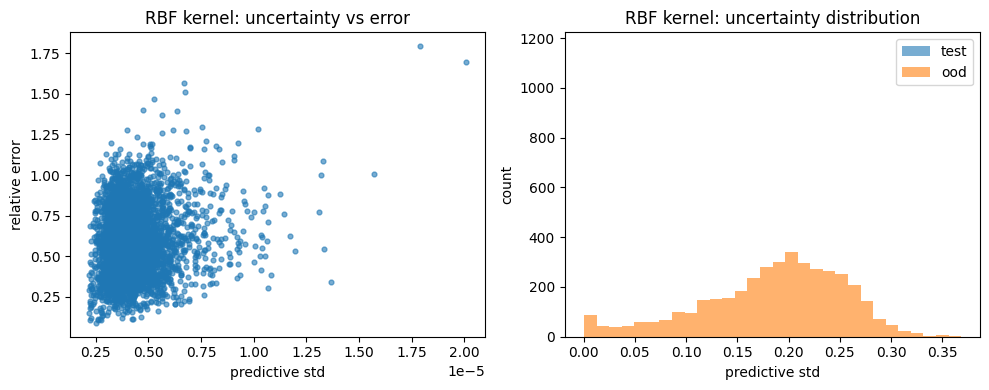

In [282]:
### out-of-distribution testing
if HAS_OOD:
    rbf_ood_uncertainty = None
    for ood_case in OOD_CASES:
        start = time.perf_counter()
        ood_pred_flat, ood_pred_std = model.predict(ood_case['X_model'], return_std=True)
        rbf_ood_predict_time = time.perf_counter() - start
        ood_pred_case = decode_prediction(ood_pred_flat)
        rbf_ood_uncertainty_case = sample_uncertainty(decode_std(ood_pred_std))
        rbf_ood_error = relative_errors(ood_pred_case, ood_case['Y'])
        ood_e = np.mean(rbf_ood_error)
        add_result(
            'vanilla', 'RBF', 'ood', rbf_ood_error,
            ood_filename=ood_case['ood_filename'],
            length_scale=bandwidth, alpha=ALPHA,
            train_time_seconds=rbf_train_time,
            predict_time_seconds=rbf_ood_predict_time,
        )
        if ood_case is OOD_VIS_CASE:
            ood_pred = ood_pred_case
            rbf_ood_uncertainty = rbf_ood_uncertainty_case
            rbf_ood_std = decode_std(ood_pred_std)
        print(f"RBF kernel [{ood_case['ood_filename']}]: out-of-distribution error is {ood_e:.2e}.")
        print(f"RBF kernel [{ood_case['ood_filename']}]: OOD predict time is {rbf_ood_predict_time:.2f}s.\n")
else:
    ood_pred = None
    rbf_ood_uncertainty = None
    rbf_ood_std = None
    print('RBF kernel: OOD evaluation skipped.\n')

plot_uncertainty('RBF kernel', rbf_test_uncertainty, rbf_test_error, rbf_ood_uncertainty)


Matern kernel: test error is 8.32e-01.
Matern kernel: train time is 14.79s, test predict time is 3.33s.

Matern kernel [ood_init.h5]: out-of-distribution error is 8.00e-01.
Matern kernel [ood_init.h5]: OOD predict time is 3.39s.

Matern kernel [ood_par_init.h5]: out-of-distribution error is 8.43e-01.
Matern kernel [ood_par_init.h5]: OOD predict time is 3.37s.

Matern kernel [ood_par_kernel.h5]: out-of-distribution error is 7.43e-01.
Matern kernel [ood_par_kernel.h5]: OOD predict time is 3.33s.

Matern kernel [ood_par_scale.h5]: out-of-distribution error is 7.30e-01.
Matern kernel [ood_par_scale.h5]: OOD predict time is 3.39s.

Matern kernel [ood_par_var.h5]: out-of-distribution error is 7.53e-01.
Matern kernel [ood_par_var.h5]: OOD predict time is 3.36s.



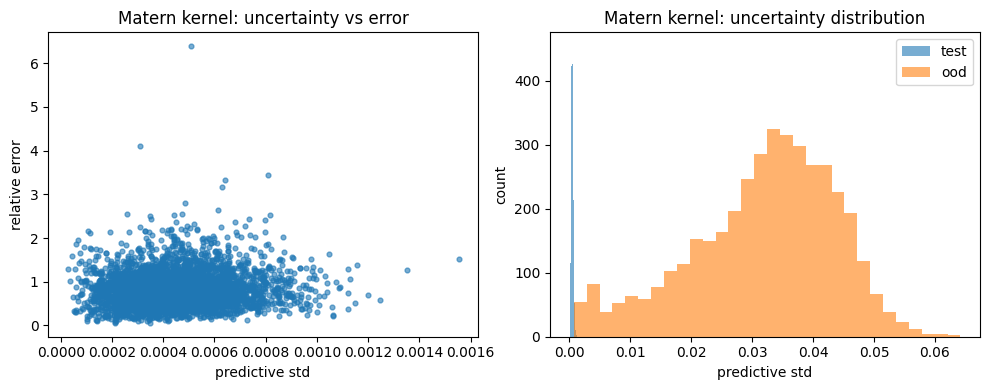

In [283]:
##################### Matern kernel
bandwidth = VANILLA_MATERN_LENGTH_SCALE
nu = VANILLA_MATERN_NU
kernel = Matern(length_scale=bandwidth, nu=nu)
model = GaussianProcessRegressor(kernel, alpha=ALPHA, optimizer=None)

start = time.perf_counter()
model.fit(X_train_model, Y_train_model)
matern_train_time = time.perf_counter() - start

# prediction
start = time.perf_counter()
matern_pred_flat, matern_pred_std = model.predict(X_test_model, return_std=True)
matern_test_predict_time = time.perf_counter() - start

matern_pred = decode_prediction(matern_pred_flat)
matern_test_uncertainty = sample_uncertainty(decode_std(matern_pred_std))
matern_test_error = relative_errors(matern_pred, Y_test)
matern_e = np.mean(matern_test_error)
add_result(
    'vanilla', 'Matern', 'test', matern_test_error,
    length_scale=bandwidth, nu=nu, alpha=ALPHA,
    train_time_seconds=matern_train_time,
    predict_time_seconds=matern_test_predict_time,
)
print(f'Matern kernel: test error is {matern_e:.2e}.')
print(f'Matern kernel: train time is {matern_train_time:.2f}s, test predict time is {matern_test_predict_time:.2f}s.\n')

### out-of-distribution testing
if HAS_OOD:
    matern_ood_uncertainty = None
    for ood_case in OOD_CASES:
        start = time.perf_counter()
        matern_ood_pred_flat, matern_ood_pred_std = model.predict(ood_case['X_model'], return_std=True)
        matern_ood_predict_time = time.perf_counter() - start
        matern_ood_pred_case = decode_prediction(matern_ood_pred_flat)
        matern_ood_uncertainty_case = sample_uncertainty(decode_std(matern_ood_pred_std))
        matern_ood_error = relative_errors(matern_ood_pred_case, ood_case['Y'])
        matern_ood_e = np.mean(matern_ood_error)
        add_result(
            'vanilla', 'Matern', 'ood', matern_ood_error,
            ood_filename=ood_case['ood_filename'],
            length_scale=bandwidth, nu=nu, alpha=ALPHA,
            train_time_seconds=matern_train_time,
            predict_time_seconds=matern_ood_predict_time,
        )
        if ood_case is OOD_VIS_CASE:
            matern_ood_pred = matern_ood_pred_case
            matern_ood_uncertainty = matern_ood_uncertainty_case
            matern_ood_std = decode_std(matern_ood_pred_std)
        print(f"Matern kernel [{ood_case['ood_filename']}]: out-of-distribution error is {matern_ood_e:.2e}.")
        print(f"Matern kernel [{ood_case['ood_filename']}]: OOD predict time is {matern_ood_predict_time:.2f}s.\n")
else:
    matern_ood_pred = None
    matern_ood_uncertainty = None
    matern_ood_std = None
    print('Matern kernel: OOD evaluation skipped.\n')

plot_uncertainty('Matern kernel', matern_test_uncertainty, matern_test_error, matern_ood_uncertainty)


In [284]:
results_df = results_table()
display(results_df)
results_df.to_csv(results_path, index=False)
print(f'Saved results to {results_path}')

results_df


,pde,task_mode,method,kernel,split,n_train,n_eval,ics_per_param,mean_relative_error,std_relative_error,...,coef_model_dim,y_model_dim,fw1_x_model_dim,fw1_y_model_dim,train_time_seconds,predict_time_seconds,length_scale,alpha,ood_filename,nu
0,Param_wave,sample,vanilla,RBF,test,10000,4000,NaN,0.592857,0.213223,...,64,8192,NaN,NaN,14.812503,3.311175,10,1.000000e-10,NaN,NaN
1,Param_wave,sample,vanilla,RBF,ood,10000,4000,NaN,134.739613,62.451056,...,64,8192,NaN,NaN,14.812503,3.269712,10,1.000000e-10,ood_init.h5,NaN
2,Param_wave,sample,vanilla,RBF,ood,10000,4000,NaN,151.345012,63.614074,...,64,8192,NaN,NaN,14.812503,3.276233,10,1.000000e-10,ood_par_init.h5,NaN
3,Param_wave,sample,vanilla,RBF,ood,10000,4000,NaN,0.506259,0.189993,...,64,8192,NaN,NaN,14.812503,3.260481,10,1.000000e-10,ood_par_kernel.h5,NaN
4,Param_wave,sample,vanilla,RBF,ood,10000,4000,NaN,0.521325,0.209537,...,64,8192,NaN,NaN,14.812503,3.350124,10,1.000000e-10,ood_par_scale.h5,NaN
5,Param_wave,sample,vanilla,RBF,ood,10000,4000,NaN,0.553514,0.203029,...,64,8192,NaN,NaN,14.812503,3.525560,10,1.000000e-10,ood_par_var.h5,NaN
6,Param_wave,sample,vanilla,Matern,test,10000,4000,NaN,0.831625,0.402569,...,64,8192,NaN,NaN,14.793930,3.329853,100,1.000000e-10,NaN,1.5
7,Param_wave,sample,vanilla,Matern,ood,10000,4000,NaN,0.800188,0.260290,...,64,8192,NaN,NaN,14.793930,3.387537,100,1.000000e-10,ood_init.h5,1.5
8,Param_wave,sample,vanilla,Matern,ood,10000,4000,NaN,0.843025,0.289156,...,64,8192,NaN,NaN,14.793930,3.373414,100,1.000000e-10,ood_par_init.h5,1.5
9,Param_wave,sample,vanilla,Matern,ood,10000,4000,NaN,0.743398,0.383662,...,64,8192,NaN,NaN,14.793930,3.333925,100,1.000000e-10,ood_par_kernel.h5,1.5


Saved results to Framework2/results_Param_wave_sample_no_pca_all_ood.csv


,pde,task_mode,method,kernel,split,n_train,n_eval,ics_per_param,mean_relative_error,std_relative_error,...,coef_model_dim,y_model_dim,fw1_x_model_dim,fw1_y_model_dim,train_time_seconds,predict_time_seconds,length_scale,alpha,ood_filename,nu
0,Param_wave,sample,vanilla,RBF,test,10000,4000,NaN,0.592857,0.213223,...,64,8192,NaN,NaN,14.812503,3.311175,10,1.000000e-10,NaN,NaN
1,Param_wave,sample,vanilla,RBF,ood,10000,4000,NaN,134.739613,62.451056,...,64,8192,NaN,NaN,14.812503,3.269712,10,1.000000e-10,ood_init.h5,NaN
2,Param_wave,sample,vanilla,RBF,ood,10000,4000,NaN,151.345012,63.614074,...,64,8192,NaN,NaN,14.812503,3.276233,10,1.000000e-10,ood_par_init.h5,NaN
3,Param_wave,sample,vanilla,RBF,ood,10000,4000,NaN,0.506259,0.189993,...,64,8192,NaN,NaN,14.812503,3.260481,10,1.000000e-10,ood_par_kernel.h5,NaN
4,Param_wave,sample,vanilla,RBF,ood,10000,4000,NaN,0.521325,0.209537,...,64,8192,NaN,NaN,14.812503,3.350124,10,1.000000e-10,ood_par_scale.h5,NaN
5,Param_wave,sample,vanilla,RBF,ood,10000,4000,NaN,0.553514,0.203029,...,64,8192,NaN,NaN,14.812503,3.525560,10,1.000000e-10,ood_par_var.h5,NaN
6,Param_wave,sample,vanilla,Matern,test,10000,4000,NaN,0.831625,0.402569,...,64,8192,NaN,NaN,14.793930,3.329853,100,1.000000e-10,NaN,1.5
7,Param_wave,sample,vanilla,Matern,ood,10000,4000,NaN,0.800188,0.260290,...,64,8192,NaN,NaN,14.793930,3.387537,100,1.000000e-10,ood_init.h5,1.5
8,Param_wave,sample,vanilla,Matern,ood,10000,4000,NaN,0.843025,0.289156,...,64,8192,NaN,NaN,14.793930,3.373414,100,1.000000e-10,ood_par_init.h5,1.5
9,Param_wave,sample,vanilla,Matern,ood,10000,4000,NaN,0.743398,0.383662,...,64,8192,NaN,NaN,14.793930,3.333925,100,1.000000e-10,ood_par_kernel.h5,1.5


# Our Method

Product GPR: test error is 3.33e-02.
Product GPR: train time is 17.48s, test predict time is 4.19s.

Product GPR [ood_init.h5]: out-of-distribution error is 3.81e-01.
Product GPR [ood_init.h5]: OOD predict time is 4.23s.

Product GPR [ood_par_init.h5]: out-of-distribution error is 9.77e-01.
Product GPR [ood_par_init.h5]: OOD predict time is 4.21s.

Product GPR [ood_par_kernel.h5]: out-of-distribution error is 6.05e-01.
Product GPR [ood_par_kernel.h5]: OOD predict time is 4.20s.

Product GPR [ood_par_scale.h5]: out-of-distribution error is 7.63e-01.
Product GPR [ood_par_scale.h5]: OOD predict time is 4.28s.

Product GPR [ood_par_var.h5]: out-of-distribution error is 2.67e-02.
Product GPR [ood_par_var.h5]: OOD predict time is 4.19s.



,pde,task_mode,method,kernel,split,n_train,n_eval,ics_per_param,mean_relative_error,std_relative_error,...,train_time_seconds,predict_time_seconds,length_scale,alpha,ood_filename,nu,coef_length_scale,coef_nu,state_length_scale,state_nu
0,Param_wave,sample,vanilla,RBF,test,10000,4000,NaN,0.592857,0.213223,...,14.812503,3.311175,10.0,1.000000e-10,NaN,NaN,NaN,NaN,NaN,NaN
1,Param_wave,sample,vanilla,RBF,ood,10000,4000,NaN,134.739613,62.451056,...,14.812503,3.269712,10.0,1.000000e-10,ood_init.h5,NaN,NaN,NaN,NaN,NaN
2,Param_wave,sample,vanilla,RBF,ood,10000,4000,NaN,151.345012,63.614074,...,14.812503,3.276233,10.0,1.000000e-10,ood_par_init.h5,NaN,NaN,NaN,NaN,NaN
3,Param_wave,sample,vanilla,RBF,ood,10000,4000,NaN,0.506259,0.189993,...,14.812503,3.260481,10.0,1.000000e-10,ood_par_kernel.h5,NaN,NaN,NaN,NaN,NaN
4,Param_wave,sample,vanilla,RBF,ood,10000,4000,NaN,0.521325,0.209537,...,14.812503,3.350124,10.0,1.000000e-10,ood_par_scale.h5,NaN,NaN,NaN,NaN,NaN
5,Param_wave,sample,vanilla,RBF,ood,10000,4000,NaN,0.553514,0.203029,...,14.812503,3.525560,10.0,1.000000e-10,ood_par_var.h5,NaN,NaN,NaN,NaN,NaN
6,Param_wave,sample,vanilla,Matern,test,10000,4000,NaN,0.831625,0.402569,...,14.793930,3.329853,100.0,1.000000e-10,NaN,1.5,NaN,NaN,NaN,NaN
7,Param_wave,sample,vanilla,Matern,ood,10000,4000,NaN,0.800188,0.260290,...,14.793930,3.387537,100.0,1.000000e-10,ood_init.h5,1.5,NaN,NaN,NaN,NaN
8,Param_wave,sample,vanilla,Matern,ood,10000,4000,NaN,0.843025,0.289156,...,14.793930,3.373414,100.0,1.000000e-10,ood_par_init.h5,1.5,NaN,NaN,NaN,NaN
9,Param_wave,sample,vanilla,Matern,ood,10000,4000,NaN,0.743398,0.383662,...,14.793930,3.333925,100.0,1.000000e-10,ood_par_kernel.h5,1.5,NaN,NaN,NaN,NaN


Saved results to Framework2/results_Param_wave_sample_no_pca_all_ood.csv


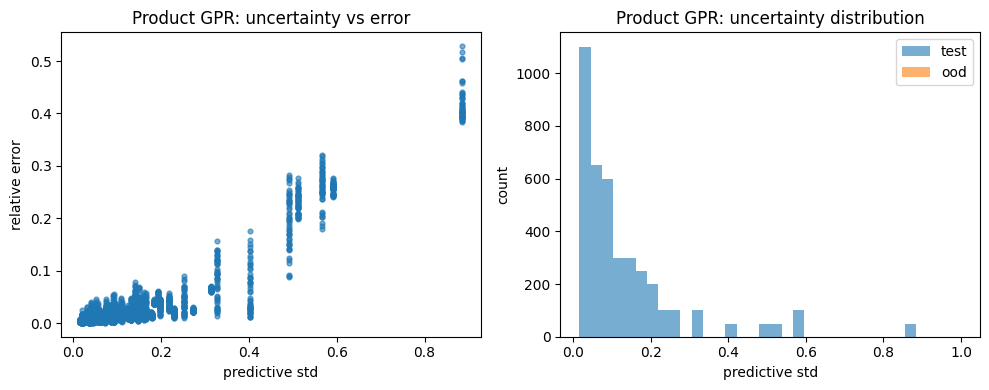

In [285]:

from sklearn.gaussian_process.kernels import Kernel


class ProductPDEKernel(Kernel):
    def __init__(self, n_u, coef_kernel=None, state_kernel=None):
        self.n_u = n_u
        self.coef_kernel = coef_kernel
        self.state_kernel = state_kernel

    def __call__(self, X, Y=None, eval_gradient=False):
        if eval_gradient:
            raise ValueError('Gradient is not implemented. Use optimizer=None.')

        X_u = X[:, :self.n_u]
        X_c = X[:, self.n_u:]

        if Y is None:
            Y_u = None
            Y_c = None
        else:
            Y_u = Y[:, :self.n_u]
            Y_c = Y[:, self.n_u:]

        return self.state_kernel(X_u, Y_u) * self.coef_kernel(X_c, Y_c)

    def diag(self, X):
        X_u = X[:, :self.n_u]
        X_c = X[:, self.n_u:]
        return self.state_kernel.diag(X_u) * self.coef_kernel.diag(X_c)

    def is_stationary(self):
        return self.state_kernel.is_stationary() and self.coef_kernel.is_stationary()


if TASK_MODE == 'parameter_set':
    ##################### Framework1 method: coefficients -> all fixed-IC trajectories, Matern kernel
    bandwidth = FRAMEWORK1_MATERN_LENGTH_SCALE
    nu = FRAMEWORK1_MATERN_NU
    kernel = Matern(length_scale=bandwidth, nu=nu)
    model = GaussianProcessRegressor(kernel, alpha=ALPHA, optimizer=None)
    start = time.perf_counter()
    model.fit(fw1_X_train_model, fw1_Y_train_model)
    product_train_time = time.perf_counter() - start

    start = time.perf_counter()
    product_pred_flat, product_pred_std = model.predict(fw1_X_test_model, return_std=True)
    product_test_predict_time = time.perf_counter() - start
    product_pred = decode_fw1_prediction(product_pred_flat)
    product_test_uncertainty = sample_uncertainty(decode_fw1_std(product_pred_std))
    product_test_error = relative_errors(product_pred, fw1_Y_test)
    product_e = np.mean(product_test_error)
    add_result(
        'framework1', 'Matern', 'test', product_test_error,
        length_scale=bandwidth, nu=nu, alpha=ALPHA,
        n_train=fw1_X_train.shape[0], n_eval=len(product_test_error),
        train_time_seconds=product_train_time,
        predict_time_seconds=product_test_predict_time,
    )
    print(f'Framework1 Matern: test error is {product_e:.2e}.')
    print(f'Framework1 Matern: train time is {product_train_time:.2f}s, test predict time is {product_test_predict_time:.2f}s.\n')

    if HAS_OOD:
        product_ood_uncertainty = None
        for ood_case in OOD_CASES:
            start = time.perf_counter()
            product_ood_pred_flat, product_ood_pred_std = model.predict(ood_case['fw1_X_model'], return_std=True)
            product_ood_predict_time = time.perf_counter() - start
            product_ood_pred_case = decode_fw1_prediction(product_ood_pred_flat)
            product_ood_uncertainty_case = sample_uncertainty(decode_fw1_std(product_ood_pred_std))
            product_ood_error = relative_errors(product_ood_pred_case, ood_case['fw1_Y'])
            product_ood_e = np.mean(product_ood_error)
            add_result(
                'framework1', 'Matern', 'ood', product_ood_error,
                ood_filename=ood_case['ood_filename'],
                length_scale=bandwidth, nu=nu, alpha=ALPHA,
                n_train=fw1_X_train.shape[0], n_eval=len(product_ood_error),
                train_time_seconds=product_train_time,
                predict_time_seconds=product_ood_predict_time,
            )
            if ood_case is OOD_VIS_CASE:
                product_ood_pred = product_ood_pred_case
                product_ood_uncertainty = product_ood_uncertainty_case
                product_ood_std = decode_fw1_std(product_ood_pred_std)
            print(f"Framework1 Matern [{ood_case['ood_filename']}]: out-of-distribution error is {product_ood_e:.2e}.")
            print(f"Framework1 Matern [{ood_case['ood_filename']}]: OOD predict time is {product_ood_predict_time:.2f}s.\n")
    else:
        product_ood_pred = None
        product_ood_uncertainty = None
        product_ood_std = None
        print('Framework1 Matern: OOD evaluation skipped.\n')

    #plot_uncertainty('Framework1 Matern', product_test_uncertainty, product_test_error, product_ood_uncertainty)

else:
    ##################### Framework2 product Matern with GaussianProcessRegressor
    coef_bandwidth = PRODUCT_COEF_LENGTH_SCALE
    coef_nu = PRODUCT_COEF_NU
    state_bandwidth = PRODUCT_STATE_LENGTH_SCALE
    state_nu = PRODUCT_STATE_NU

    product_kernel = ProductPDEKernel(
        n_u=X_train_model.shape[1],
        coef_kernel=Matern(length_scale=coef_bandwidth, nu=coef_nu),
        state_kernel=Matern(length_scale=state_bandwidth, nu=state_nu),
    )

    X_train_product = np.hstack([X_train_model, coef_train_model])
    X_test_product = np.hstack([X_test_model, coef_test_model])
    X_ood_product = np.hstack([X_ood_model, coef_ood_model]) if HAS_OOD else None
    for ood_case in OOD_CASES:
        ood_case['X_product'] = np.hstack([ood_case['X_model'], ood_case['coef_model']])

    model = GaussianProcessRegressor(product_kernel, alpha=ALPHA, optimizer=None)

    start = time.perf_counter()
    model.fit(X_train_product, Y_train_model)
    product_train_time = time.perf_counter() - start

    start = time.perf_counter()
    product_pred_flat, product_pred_std = model.predict(X_test_product, return_std=True)
    product_test_predict_time = time.perf_counter() - start
    product_pred = decode_prediction(product_pred_flat)
    product_test_uncertainty = sample_uncertainty(decode_std(product_pred_std))
    product_test_error = relative_errors(product_pred, Y_test)
    product_e = np.mean(product_test_error)
    add_result(
        'product_gpr', 'Matern x Matern', 'test', product_test_error,
        coef_length_scale=coef_bandwidth, coef_nu=coef_nu,
        state_length_scale=state_bandwidth, state_nu=state_nu, alpha=ALPHA,
        train_time_seconds=product_train_time,
        predict_time_seconds=product_test_predict_time,
    )
    print(f'Product GPR: test error is {product_e:.2e}.')
    print(f'Product GPR: train time is {product_train_time:.2f}s, test predict time is {product_test_predict_time:.2f}s.\n')

    if HAS_OOD:
        product_ood_uncertainty = None
        for ood_case in OOD_CASES:
            start = time.perf_counter()
            product_ood_pred_flat, product_ood_pred_std = model.predict(ood_case['X_product'], return_std=True)
            product_ood_predict_time = time.perf_counter() - start
            product_ood_pred_case = decode_prediction(product_ood_pred_flat)
            product_ood_uncertainty_case = sample_uncertainty(decode_std(product_ood_pred_std))
            product_ood_error = relative_errors(product_ood_pred_case, ood_case['Y'])
            product_ood_e = np.mean(product_ood_error)
            add_result(
                'product_gpr', 'Matern x Matern', 'ood', product_ood_error,
                ood_filename=ood_case['ood_filename'],
                coef_length_scale=coef_bandwidth, coef_nu=coef_nu,
                state_length_scale=state_bandwidth, state_nu=state_nu, alpha=ALPHA,
                train_time_seconds=product_train_time,
                predict_time_seconds=product_ood_predict_time,
            )
            if ood_case is OOD_VIS_CASE:
                product_ood_pred = product_ood_pred_case
                product_ood_uncertainty = product_ood_uncertainty_case
                product_ood_std = decode_std(product_ood_pred_std)
            print(f"Product GPR [{ood_case['ood_filename']}]: out-of-distribution error is {product_ood_e:.2e}.")
            print(f"Product GPR [{ood_case['ood_filename']}]: OOD predict time is {product_ood_predict_time:.2f}s.\n")
    else:
        product_ood_pred = None
        product_ood_uncertainty = None
        product_ood_std = None
        print('Product GPR: OOD evaluation skipped.\n')

    plot_uncertainty('Product GPR', product_test_uncertainty, product_test_error, product_ood_uncertainty)

results_df = results_table()
display(results_df)
results_df.to_csv(results_path, index=False)
print(f'Saved results to {results_path}')


Product RBF GPR: test error is 3.52e-02.
Product RBF GPR: train time is 17.57s, test predict time is 4.18s.

Product RBF GPR [ood_init.h5]: out-of-distribution error is 3.79e-01.
Product RBF GPR [ood_init.h5]: OOD predict time is 4.07s.

Product RBF GPR [ood_par_init.h5]: out-of-distribution error is 9.96e-01.
Product RBF GPR [ood_par_init.h5]: OOD predict time is 4.08s.

Product RBF GPR [ood_par_kernel.h5]: out-of-distribution error is 6.83e-01.
Product RBF GPR [ood_par_kernel.h5]: OOD predict time is 4.05s.

Product RBF GPR [ood_par_scale.h5]: out-of-distribution error is 8.38e-01.
Product RBF GPR [ood_par_scale.h5]: OOD predict time is 4.01s.

Product RBF GPR [ood_par_var.h5]: out-of-distribution error is 2.88e-02.
Product RBF GPR [ood_par_var.h5]: OOD predict time is 3.98s.



,pde,task_mode,method,kernel,split,n_train,n_eval,ics_per_param,mean_relative_error,std_relative_error,...,train_time_seconds,predict_time_seconds,length_scale,alpha,ood_filename,nu,coef_length_scale,coef_nu,state_length_scale,state_nu
0,Param_wave,sample,vanilla,RBF,test,10000,4000,NaN,0.592857,0.213223,...,14.812503,3.311175,10.0,1.000000e-10,NaN,NaN,NaN,NaN,NaN,NaN
1,Param_wave,sample,vanilla,RBF,ood,10000,4000,NaN,134.739613,62.451056,...,14.812503,3.269712,10.0,1.000000e-10,ood_init.h5,NaN,NaN,NaN,NaN,NaN
2,Param_wave,sample,vanilla,RBF,ood,10000,4000,NaN,151.345012,63.614074,...,14.812503,3.276233,10.0,1.000000e-10,ood_par_init.h5,NaN,NaN,NaN,NaN,NaN
3,Param_wave,sample,vanilla,RBF,ood,10000,4000,NaN,0.506259,0.189993,...,14.812503,3.260481,10.0,1.000000e-10,ood_par_kernel.h5,NaN,NaN,NaN,NaN,NaN
4,Param_wave,sample,vanilla,RBF,ood,10000,4000,NaN,0.521325,0.209537,...,14.812503,3.350124,10.0,1.000000e-10,ood_par_scale.h5,NaN,NaN,NaN,NaN,NaN
5,Param_wave,sample,vanilla,RBF,ood,10000,4000,NaN,0.553514,0.203029,...,14.812503,3.525560,10.0,1.000000e-10,ood_par_var.h5,NaN,NaN,NaN,NaN,NaN
6,Param_wave,sample,vanilla,Matern,test,10000,4000,NaN,0.831625,0.402569,...,14.793930,3.329853,100.0,1.000000e-10,NaN,1.5,NaN,NaN,NaN,NaN
7,Param_wave,sample,vanilla,Matern,ood,10000,4000,NaN,0.800188,0.260290,...,14.793930,3.387537,100.0,1.000000e-10,ood_init.h5,1.5,NaN,NaN,NaN,NaN
8,Param_wave,sample,vanilla,Matern,ood,10000,4000,NaN,0.843025,0.289156,...,14.793930,3.373414,100.0,1.000000e-10,ood_par_init.h5,1.5,NaN,NaN,NaN,NaN
9,Param_wave,sample,vanilla,Matern,ood,10000,4000,NaN,0.743398,0.383662,...,14.793930,3.333925,100.0,1.000000e-10,ood_par_kernel.h5,1.5,NaN,NaN,NaN,NaN


Saved results to Framework2/results_Param_wave_sample_no_pca_all_ood.csv


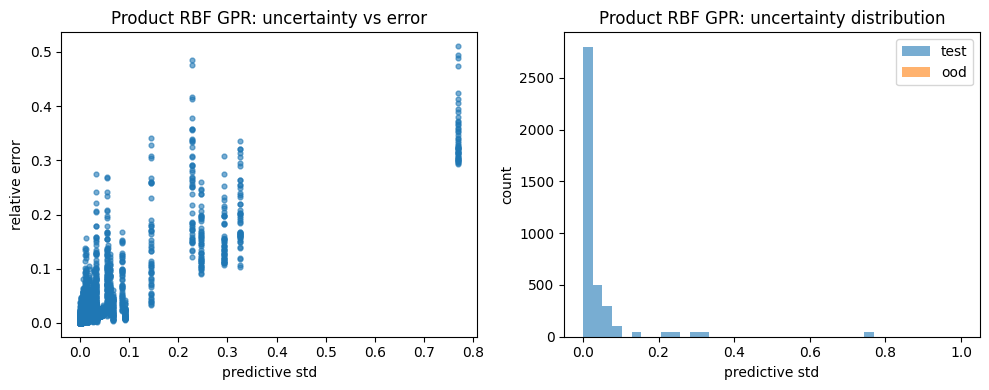

In [286]:

if TASK_MODE == 'parameter_set':
    ##################### Framework1 method: coefficients -> all fixed-IC trajectories, RBF kernel
    bandwidth = FRAMEWORK1_RBF_LENGTH_SCALE
    kernel = RBF(length_scale=bandwidth)
    model = GaussianProcessRegressor(kernel, alpha=ALPHA, optimizer=None)
    start = time.perf_counter()
    model.fit(fw1_X_train_model, fw1_Y_train_model)
    product_rbf_train_time = time.perf_counter() - start

    start = time.perf_counter()
    product_rbf_pred_flat, product_rbf_pred_std = model.predict(fw1_X_test_model, return_std=True)
    product_rbf_test_predict_time = time.perf_counter() - start
    product_rbf_pred = decode_fw1_prediction(product_rbf_pred_flat)
    product_rbf_test_uncertainty = sample_uncertainty(decode_fw1_std(product_rbf_pred_std))
    product_rbf_test_error = relative_errors(product_rbf_pred, fw1_Y_test)
    product_rbf_e = np.mean(product_rbf_test_error)
    add_result(
        'framework1', 'RBF', 'test', product_rbf_test_error,
        length_scale=bandwidth, alpha=ALPHA,
        n_train=fw1_X_train.shape[0], n_eval=len(product_rbf_test_error),
        train_time_seconds=product_rbf_train_time,
        predict_time_seconds=product_rbf_test_predict_time,
    )
    print(f'Framework1 RBF: test error is {product_rbf_e:.2e}.')
    print(f'Framework1 RBF: train time is {product_rbf_train_time:.2f}s, test predict time is {product_rbf_test_predict_time:.2f}s.\n')

    if HAS_OOD:
        product_rbf_ood_uncertainty = None
        for ood_case in OOD_CASES:
            start = time.perf_counter()
            product_rbf_ood_pred_flat, product_rbf_ood_pred_std = model.predict(ood_case['fw1_X_model'], return_std=True)
            product_rbf_ood_predict_time = time.perf_counter() - start
            product_rbf_ood_pred_case = decode_fw1_prediction(product_rbf_ood_pred_flat)
            product_rbf_ood_uncertainty_case = sample_uncertainty(decode_fw1_std(product_rbf_ood_pred_std))
            product_rbf_ood_error = relative_errors(product_rbf_ood_pred_case, ood_case['fw1_Y'])
            product_rbf_ood_e = np.mean(product_rbf_ood_error)
            add_result(
                'framework1', 'RBF', 'ood', product_rbf_ood_error,
                ood_filename=ood_case['ood_filename'],
                length_scale=bandwidth, alpha=ALPHA,
                n_train=fw1_X_train.shape[0], n_eval=len(product_rbf_ood_error),
                train_time_seconds=product_rbf_train_time,
                predict_time_seconds=product_rbf_ood_predict_time,
            )
            if ood_case is OOD_VIS_CASE:
                product_rbf_ood_pred = product_rbf_ood_pred_case
                product_rbf_ood_uncertainty = product_rbf_ood_uncertainty_case
                product_rbf_ood_std = decode_fw1_std(product_rbf_ood_pred_std)
            print(f"Framework1 RBF [{ood_case['ood_filename']}]: out-of-distribution error is {product_rbf_ood_e:.2e}.")
            print(f"Framework1 RBF [{ood_case['ood_filename']}]: OOD predict time is {product_rbf_ood_predict_time:.2f}s.\n")
    else:
        product_rbf_ood_pred = None
        product_rbf_ood_uncertainty = None
        product_rbf_ood_std = None
        print('Framework1 RBF: OOD evaluation skipped.\n')

    #plot_uncertainty('Framework1 RBF', product_rbf_test_uncertainty, product_rbf_test_error, product_rbf_ood_uncertainty)

else:
    ##################### Product RBF with GaussianProcessRegressor
    coef_bandwidth = PRODUCT_RBF_COEF_LENGTH_SCALE
    state_bandwidth = PRODUCT_RBF_STATE_LENGTH_SCALE

    product_rbf_kernel = ProductPDEKernel(
        n_u=X_train_model.shape[1],
        coef_kernel=RBF(length_scale=coef_bandwidth),
        state_kernel=RBF(length_scale=state_bandwidth),
    )

    X_train_product = np.hstack([X_train_model, coef_train_model])
    X_test_product = np.hstack([X_test_model, coef_test_model])
    X_ood_product = np.hstack([X_ood_model, coef_ood_model]) if HAS_OOD else None
    for ood_case in OOD_CASES:
        ood_case['X_product'] = np.hstack([ood_case['X_model'], ood_case['coef_model']])

    model = GaussianProcessRegressor(product_rbf_kernel, alpha=ALPHA, optimizer=None)

    start = time.perf_counter()
    model.fit(X_train_product, Y_train_model)
    product_rbf_train_time = time.perf_counter() - start

    start = time.perf_counter()
    product_rbf_pred_flat, product_rbf_pred_std = model.predict(X_test_product, return_std=True)
    product_rbf_test_predict_time = time.perf_counter() - start
    product_rbf_pred = decode_prediction(product_rbf_pred_flat)
    product_rbf_test_uncertainty = sample_uncertainty(decode_std(product_rbf_pred_std))
    product_rbf_test_error = relative_errors(product_rbf_pred, Y_test)
    product_rbf_e = np.mean(product_rbf_test_error)
    add_result(
        'product_gpr', 'RBF x RBF', 'test', product_rbf_test_error,
        coef_length_scale=coef_bandwidth, state_length_scale=state_bandwidth, alpha=ALPHA,
        train_time_seconds=product_rbf_train_time,
        predict_time_seconds=product_rbf_test_predict_time,
    )
    print(f'Product RBF GPR: test error is {product_rbf_e:.2e}.')
    print(f'Product RBF GPR: train time is {product_rbf_train_time:.2f}s, test predict time is {product_rbf_test_predict_time:.2f}s.\n')

    if HAS_OOD:
        product_rbf_ood_uncertainty = None
        for ood_case in OOD_CASES:
            start = time.perf_counter()
            product_rbf_ood_pred_flat, product_rbf_ood_pred_std = model.predict(ood_case['X_product'], return_std=True)
            product_rbf_ood_predict_time = time.perf_counter() - start
            product_rbf_ood_pred_case = decode_prediction(product_rbf_ood_pred_flat)
            product_rbf_ood_uncertainty_case = sample_uncertainty(decode_std(product_rbf_ood_pred_std))
            product_rbf_ood_error = relative_errors(product_rbf_ood_pred_case, ood_case['Y'])
            product_rbf_ood_e = np.mean(product_rbf_ood_error)
            add_result(
                'product_gpr', 'RBF x RBF', 'ood', product_rbf_ood_error,
                ood_filename=ood_case['ood_filename'],
                coef_length_scale=coef_bandwidth, state_length_scale=state_bandwidth, alpha=ALPHA,
                train_time_seconds=product_rbf_train_time,
                predict_time_seconds=product_rbf_ood_predict_time,
            )
            if ood_case is OOD_VIS_CASE:
                product_rbf_ood_pred = product_rbf_ood_pred_case
                product_rbf_ood_uncertainty = product_rbf_ood_uncertainty_case
                product_rbf_ood_std = decode_std(product_rbf_ood_pred_std)
            print(f"Product RBF GPR [{ood_case['ood_filename']}]: out-of-distribution error is {product_rbf_ood_e:.2e}.")
            print(f"Product RBF GPR [{ood_case['ood_filename']}]: OOD predict time is {product_rbf_ood_predict_time:.2f}s.\n")
    else:
        product_rbf_ood_pred = None
        product_rbf_ood_uncertainty = None
        product_rbf_ood_std = None
        print('Product RBF GPR: OOD evaluation skipped.\n')

    plot_uncertainty('Product RBF GPR', product_rbf_test_uncertainty, product_rbf_test_error, product_rbf_ood_uncertainty)

results_df = results_table()
display(results_df)
results_df.to_csv(results_path, index=False)
print(f'Saved results to {results_path}')


In [299]:
MATPLOTLIB_CMAP = 'bwr'                      # colormap for trajectory fields and UQ mean surfaces
ERROR_CMAP = 'PiYG' 
UQ_PLOT_CONFIDENCE_SURFACES = True               # draw lower/upper confidence surfaces in 3D UQ plots
UQ_CONFIDENCE_SURFACE_COLOR = 'gray'        # color for 3D lower/upper confidence surfaces
UQ_CONFIDENCE_SURFACE_ALPHA = 0.3  
UQ_SURFACE_ELEV = 25                          # vertical camera angle for the 3D UQ surfaces
UQ_SURFACE_AZIM = -100  
VIS_IDX = 500                                  # parameter-set/sample index used in the final visualization cell
VIS_IC_IDX = 0                               # initial-condition index to visualize when TASK_MODE='parameter_set'
VIS_PLOT_OOD = True 

Exported clean trajectory/error image: uq_images/param_wave_ood_ood_par_init_h5_sample500_trajectory_signed_errors.png


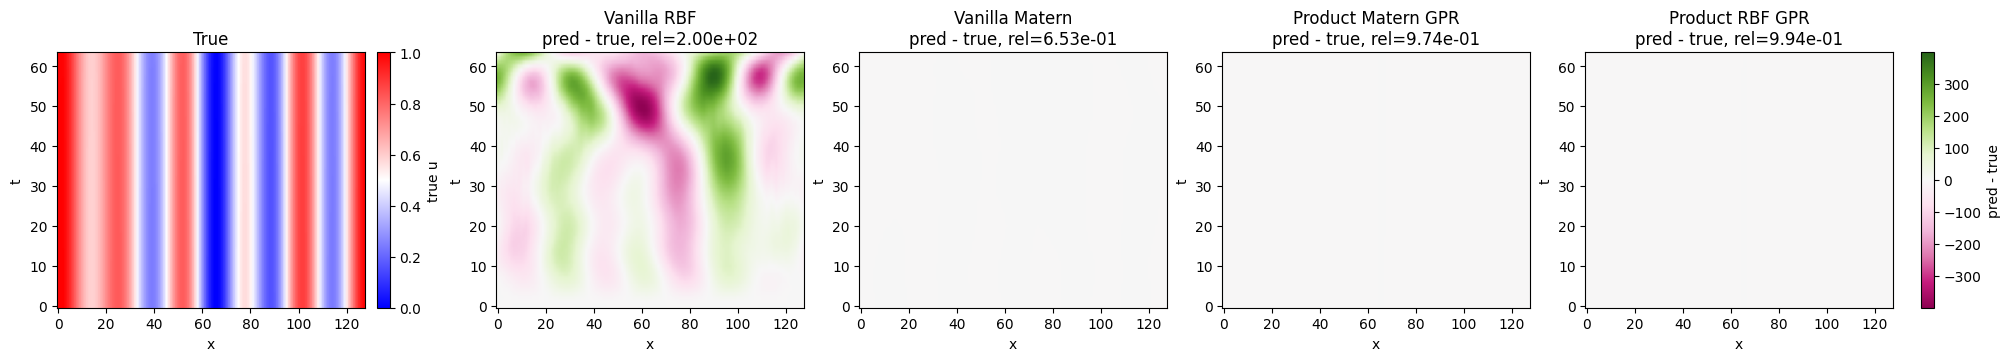

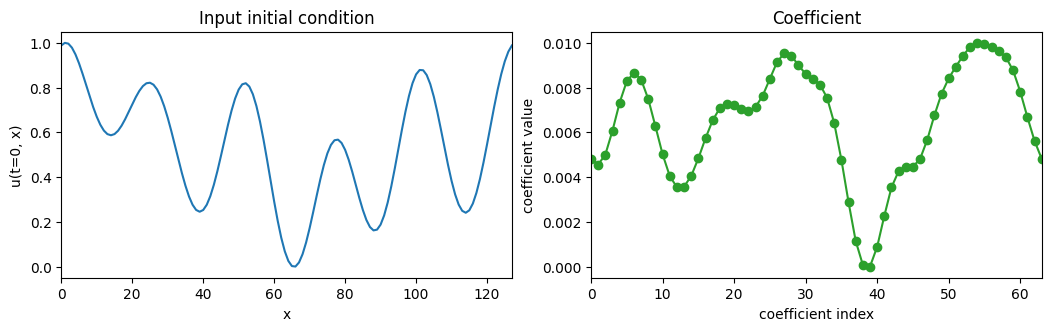

In [300]:

# visualization: true trajectory and prediction errors
idx = VIS_IDX
plot_ood = VIS_PLOT_OOD

if plot_ood and not HAS_OOD:
    raise ValueError('VIS_PLOT_OOD=True, but OOD evaluation is disabled or OOD file is unavailable.')

if TASK_MODE == 'parameter_set':
    param_idx = idx
    ic_idx = VIS_IC_IDX
    sample_idx = param_idx * ICS_PER_PARAM + ic_idx

    if plot_ood:
        target_plot = Y_ood[sample_idx]
        prediction_candidates = {
            'Vanilla RBF': globals().get('ood_pred'),
            'Vanilla Matern': globals().get('matern_ood_pred'),
            'Framework1 Matern': globals().get('product_ood_pred'),
            'Framework1 RBF': globals().get('product_rbf_ood_pred'),
        }
    else:
        target_plot = Y_test[sample_idx]
        prediction_candidates = {
            'Vanilla RBF': globals().get('pred'),
            'Vanilla Matern': globals().get('matern_pred'),
            'Framework1 Matern': globals().get('product_pred'),
            'Framework1 RBF': globals().get('product_rbf_pred'),
        }

    predictions_plot = {}
    for name, values in prediction_candidates.items():
        if values is None:
            continue
        if values.ndim == 4:
            predictions_plot[name] = values[param_idx, ic_idx]
        else:
            predictions_plot[name] = values[sample_idx]
    title_suffix = f'param {param_idx}, IC {ic_idx}'
else:
    if plot_ood:
        target_plot = Y_ood[idx]
        prediction_candidates = {
            'Vanilla RBF': globals().get('ood_pred'),
            'Vanilla Matern': globals().get('matern_ood_pred'),
            'Product Matern GPR': globals().get('product_ood_pred'),
            'Product RBF GPR': globals().get('product_rbf_ood_pred'),
        }
    else:
        target_plot = Y_test[idx]
        prediction_candidates = {
            'Vanilla RBF': globals().get('pred'),
            'Vanilla Matern': globals().get('matern_pred'),
            'Product Matern GPR': globals().get('product_pred'),
            'Product RBF GPR': globals().get('product_rbf_pred'),
        }

    predictions_plot = {
        name: values[idx]
        for name, values in prediction_candidates.items()
        if values is not None
    }
    title_suffix = ''

signed_errors_plot = {
    name: prediction_plot - target_plot
    for name, prediction_plot in predictions_plot.items()
}
max_abs_error = max((np.nanmax(np.abs(error)) for error in signed_errors_plot.values()), default=1.0)
max_abs_error = max(max_abs_error, np.finfo(float).eps)
shared_error_norm = colors.TwoSlopeNorm(vmin=-max_abs_error, vcenter=0.0, vmax=max_abs_error)

n_cols = len(predictions_plot) + 1
fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 3.5), constrained_layout=True)
if n_cols == 1:
    axes = [axes]

true_im = axes[0].imshow(target_plot, aspect='auto', origin='lower', cmap=MATPLOTLIB_CMAP)
axes[0].set_title(f'True {title_suffix}'.strip())
axes[0].set_xlabel('x')
axes[0].set_ylabel('t')
fig.colorbar(true_im, ax=axes[0], fraction=0.046, pad=0.04, label='true u')

error_images = []
for ax, (name, prediction_plot) in zip(axes[1:], predictions_plot.items()):
    error = signed_errors_plot[name]
    im = ax.imshow(error, aspect='auto', origin='lower', cmap=ERROR_CMAP, norm=shared_error_norm)
    error_images.append(im)
    rel_error = np.linalg.norm(prediction_plot - target_plot) / np.linalg.norm(target_plot)
    ax.set_title(f'{name}\npred - true, rel={rel_error:.2e}')
    ax.set_xlabel('x')
    ax.set_ylabel('t')

if error_images:
    fig.colorbar(error_images[0], ax=axes[1:], fraction=0.022, pad=0.02, label='pred - true')


def visualization_slug(text):
    cleaned = ''.join(char.lower() if char.isalnum() else '_' for char in str(text))
    return '_'.join(part for part in cleaned.split('_') if part)


def visualization_export_stem():
    split_tag = 'ood' if plot_ood else 'test'
    index_tag = f'param{VIS_IDX}_ic{VIS_IC_IDX}' if TASK_MODE == 'parameter_set' else f'sample{VIS_IDX}'
    filename_parts = [PDE_NAME, split_tag]
    if plot_ood and HAS_OOD:
        filename_parts.append(OOD_VIS_CASE['ood_filename'])
    filename_parts.extend([index_tag, 'trajectory_signed_errors'])
    return '_'.join(visualization_slug(part) for part in filename_parts)


def export_clean_trajectory_error_figure():
    UQ_IMAGE_DIR.mkdir(parents=True, exist_ok=True)
    output_path = UQ_IMAGE_DIR / f'{visualization_export_stem()}.png'
    clean_fig, clean_axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 3.5), constrained_layout=True)
    if n_cols == 1:
        clean_axes = [clean_axes]
    clean_true_im = clean_axes[0].imshow(target_plot, aspect='auto', origin='lower', cmap=MATPLOTLIB_CMAP)
    clean_axes[0].set_xlabel('x')
    clean_axes[0].set_ylabel('t')
    clean_fig.colorbar(clean_true_im, ax=clean_axes[0], fraction=0.046, pad=0.04)
    clean_error_images = []
    for ax, (name, error) in zip(clean_axes[1:], signed_errors_plot.items()):
        clean_error_images.append(ax.imshow(error, aspect='auto', origin='lower', cmap=ERROR_CMAP, norm=shared_error_norm))
        ax.set_xlabel('x')
        ax.set_ylabel('t')
    if clean_error_images:
        clean_fig.colorbar(clean_error_images[0], ax=clean_axes[1:], fraction=0.022, pad=0.02)
    clean_fig.savefig(output_path, dpi=UQ_IMAGE_DPI, bbox_inches='tight')
    plt.close(clean_fig)
    return output_path


if UQ_EXPORT_IMAGES:
    print('Exported clean trajectory/error image:', export_clean_trajectory_error_figure())

plt.show()

input_idx = sample_idx if TASK_MODE == 'parameter_set' else idx
input_plot = X_ood[input_idx] if plot_ood else X_test[input_idx]
coef_plot = coef_ood[input_idx] if plot_ood else coef_test[input_idx]
input_x = np.arange(input_plot.shape[-1])
coef_x = np.arange(coef_plot.shape[-1])
fig_input, (ax_input, ax_coef) = plt.subplots(1, 2, figsize=(10.4, 3.2), constrained_layout=True)
ax_input.plot(input_x, input_plot, color='tab:blue', linewidth=1.5)
ax_input.set_title(f'Input initial condition {title_suffix}'.strip())
ax_input.set_xlabel('x')
ax_input.set_ylabel(f'u(t={INPUT_TIME_INDEX}, x)')
ax_input.set_xlim(0, max(1, input_plot.shape[-1] - 1))
ax_coef.plot(coef_x, coef_plot, marker='o', color='tab:green', linewidth=1.5)
ax_coef.set_title(f'Coefficient {title_suffix}'.strip())
ax_coef.set_xlabel('coefficient index')
ax_coef.set_ylabel('coefficient value')
ax_coef.set_xlim(0, max(1, coef_plot.shape[-1] - 1))
plt.show()


# Pointwise predictive uncertainty

For each available prediction, plot the final-time trajectory with pointwise standard-deviation bands and the full trajectory as mean and uncertainty surfaces.

Exported clean UQ images: (PosixPath('uq_images/param_wave_ood_ood_par_init_h5_sample500_vanilla_rbf_final_time.png'), PosixPath('uq_images/param_wave_ood_ood_par_init_h5_sample500_vanilla_rbf_surface.png'))


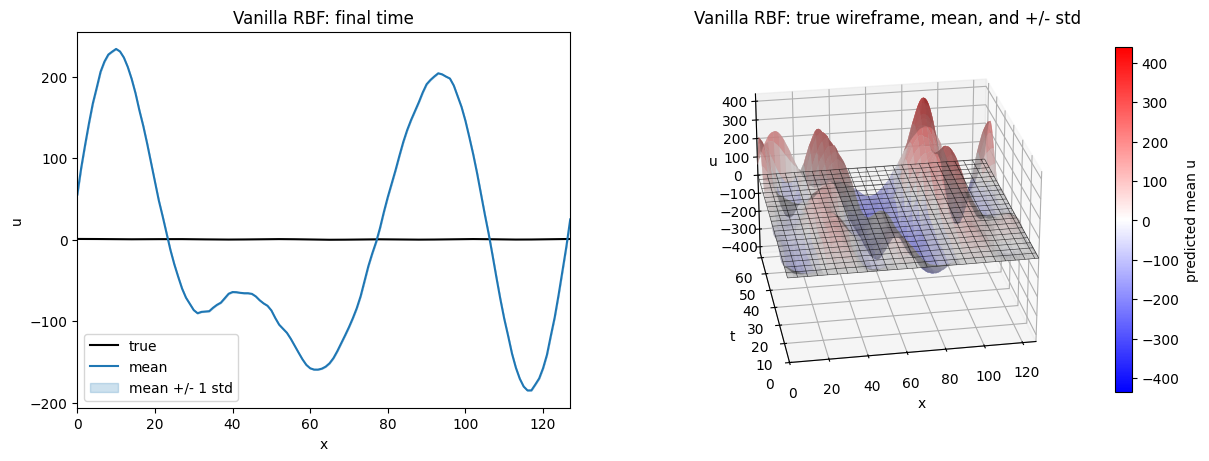

Exported clean UQ images: (PosixPath('uq_images/param_wave_ood_ood_par_init_h5_sample500_vanilla_matern_final_time.png'), PosixPath('uq_images/param_wave_ood_ood_par_init_h5_sample500_vanilla_matern_surface.png'))


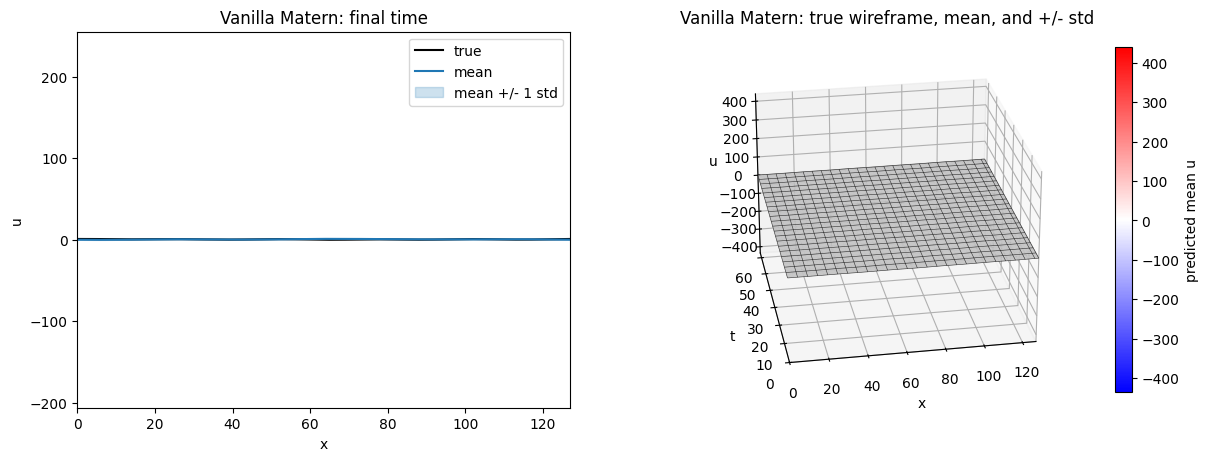

Exported clean UQ images: (PosixPath('uq_images/param_wave_ood_ood_par_init_h5_sample500_product_matern_gpr_final_time.png'), PosixPath('uq_images/param_wave_ood_ood_par_init_h5_sample500_product_matern_gpr_surface.png'))


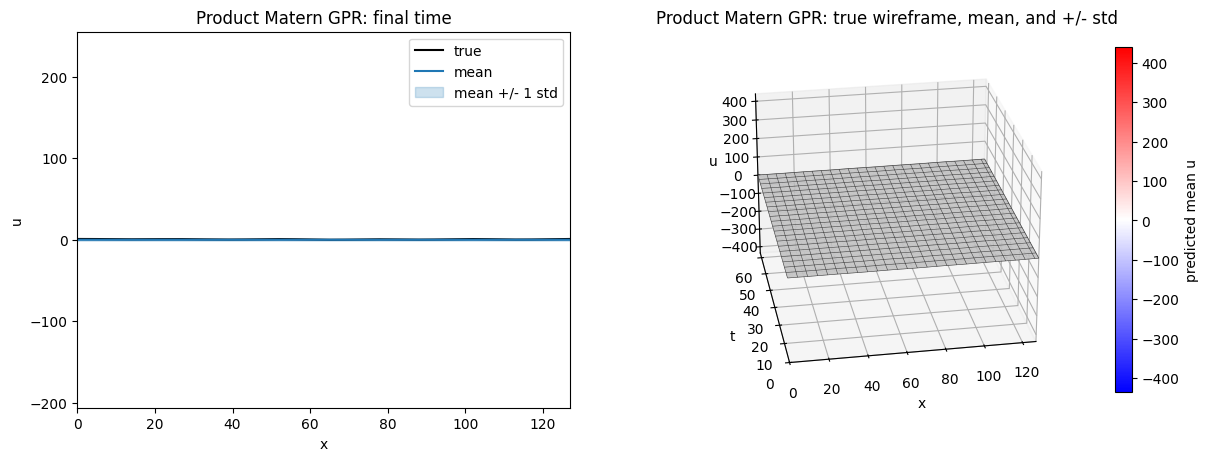

Exported clean UQ images: (PosixPath('uq_images/param_wave_ood_ood_par_init_h5_sample500_product_rbf_gpr_final_time.png'), PosixPath('uq_images/param_wave_ood_ood_par_init_h5_sample500_product_rbf_gpr_surface.png'))


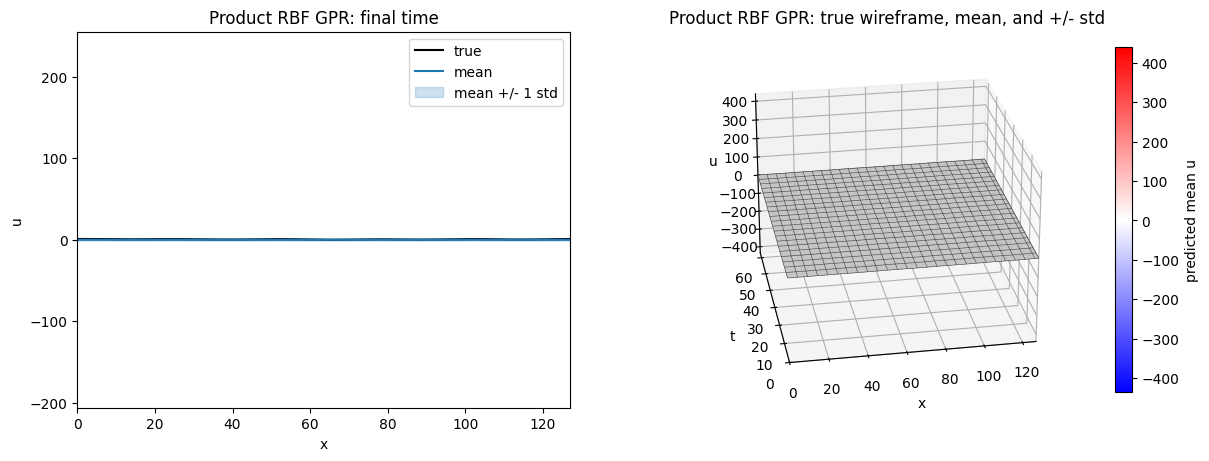

In [301]:
# UQ visualization: final-time bands and full trajectory uncertainty surfaces
def std_like_prediction(std, prediction):
    std = np.asarray(std)
    prediction = np.asarray(prediction)
    if std.shape == prediction.shape:
        return np.abs(std)
    if std.size == prediction.size:
        return np.abs(std.reshape(prediction.shape))
    if std.ndim == 1 and std.shape[0] == prediction.shape[0]:
        broadcast_shape = (std.shape[0],) + (1,) * (prediction.ndim - 1)
        return np.broadcast_to(np.abs(std).reshape(broadcast_shape), prediction.shape)
    raise ValueError(f'Cannot align std shape {std.shape} with prediction shape {prediction.shape}.')


def selected_trajectory(prediction, std):
    pointwise_std = std_like_prediction(std, prediction)
    if TASK_MODE == 'parameter_set' and prediction.ndim == 4:
        return prediction[VIS_IDX, VIS_IC_IDX], pointwise_std[VIS_IDX, VIS_IC_IDX]
    if TASK_MODE == 'parameter_set':
        sample_idx = VIS_IDX * ICS_PER_PARAM + VIS_IC_IDX
        return prediction[sample_idx], pointwise_std[sample_idx]
    return prediction[VIS_IDX], pointwise_std[VIS_IDX]


def padded_limits(values, padding_fraction=0.05):
    values = np.concatenate([np.ravel(value) for value in values])
    lower = np.nanmin(values)
    upper = np.nanmax(values)
    span = upper - lower
    padding = padding_fraction * span if span > 0 else padding_fraction * max(abs(lower), 1.0)
    return lower - padding, upper + padding


def plot_trajectory_uq(
    name,
    prediction,
    pointwise_std,
    target=None,
    line_ylim=None,
    surface_zlim=None,
    surface_norm=None,
):
    if prediction.ndim != 2:
        raise ValueError(f'{name} trajectory must have shape (time, x), got {prediction.shape}.')
    x = np.arange(prediction.shape[1])
    t = np.arange(prediction.shape[0])
    lower = prediction - UQ_STD_MULTIPLIER * pointwise_std
    upper = prediction + UQ_STD_MULTIPLIER * pointwise_std

    n_panels = 2
    fig = plt.figure(figsize=(12, 4.5), constrained_layout=True)
    ax_line = fig.add_subplot(1, n_panels, 1)
    if target is not None:
        ax_line.plot(x, target[-1], color='black', linewidth=1.5, label='true')
    ax_line.plot(x, prediction[-1], color='tab:blue', linewidth=1.5, label='mean')
    ax_line.fill_between(
        x,
        lower[-1],
        upper[-1],
        color='tab:blue',
        alpha=0.22,
        label=f'mean +/- {UQ_STD_MULTIPLIER:g} std',
    )
    ax_line.set_title(f'{name}: final time')
    ax_line.set_xlabel('x')
    ax_line.set_ylabel('u')
    ax_line.set_xlim(0, max(1, prediction.shape[1] - 1))
    if line_ylim is not None:
        ax_line.set_ylim(line_ylim)
    ax_line.legend()

    grid_x, grid_t = np.meshgrid(x, t)
    ax_surface = fig.add_subplot(1, n_panels, 2, projection='3d')
    if target is not None:
        ax_surface.plot_wireframe(
            grid_x,
            grid_t,
            target,
            color='black',
            linewidth=0.45,
            rstride=max(1, target.shape[0] // 18),
            cstride=max(1, target.shape[1] // 24),
            alpha=0.7,
        )
    mean_surface = ax_surface.plot_surface(
        grid_x,
        grid_t,
        prediction,
        cmap=MATPLOTLIB_CMAP,
        norm=surface_norm,
        linewidth=0,
        alpha=0.82,
    )
    if UQ_PLOT_CONFIDENCE_SURFACES:
        ax_surface.plot_surface(
            grid_x,
            grid_t,
            lower,
            color=UQ_CONFIDENCE_SURFACE_COLOR,
            linewidth=0,
            alpha=UQ_CONFIDENCE_SURFACE_ALPHA,
        )
        ax_surface.plot_surface(
            grid_x,
            grid_t,
            upper,
            color=UQ_CONFIDENCE_SURFACE_COLOR,
            linewidth=0,
            alpha=UQ_CONFIDENCE_SURFACE_ALPHA,
        )
    ax_surface.set_title(f'{name}: true wireframe, mean, and +/- std')
    ax_surface.set_xlabel('x')
    ax_surface.set_ylabel('t')
    ax_surface.set_zlabel('u')
    ax_surface.set_xlim(0, max(1, prediction.shape[1] - 1))
    ax_surface.set_ylim(0, max(1, prediction.shape[0] - 1))
    ax_surface.view_init(elev=UQ_SURFACE_ELEV, azim=UQ_SURFACE_AZIM)
    if surface_zlim is not None:
        ax_surface.set_zlim(surface_zlim)
    color_mappable = ScalarMappable(norm=surface_norm, cmap=MATPLOTLIB_CMAP) if surface_norm is not None else mean_surface
    color_mappable.set_array(prediction)
    fig.colorbar(color_mappable, ax=ax_surface, fraction=0.035, pad=0.08, label='predicted mean u')
    plt.show()


if VIS_PLOT_OOD:
    if not HAS_OOD:
        raise ValueError('VIS_PLOT_OOD=True, but no OOD case is available.')
    uq_target = Y_ood[VIS_IDX] if TASK_MODE == 'sample' else Y_ood[VIS_IDX * ICS_PER_PARAM + VIS_IC_IDX]
    uq_candidates = {
        'Vanilla RBF': (globals().get('ood_pred'), globals().get('rbf_ood_std')),
        'Vanilla Matern': (globals().get('matern_ood_pred'), globals().get('matern_ood_std')),
        'Framework1 Matern' if TASK_MODE == 'parameter_set' else 'Product Matern GPR': (
            globals().get('product_ood_pred'), globals().get('product_ood_std')
        ),
        'Framework1 RBF' if TASK_MODE == 'parameter_set' else 'Product RBF GPR': (
            globals().get('product_rbf_ood_pred'), globals().get('product_rbf_ood_std')
        ),
    }
else:
    uq_target = Y_test[VIS_IDX] if TASK_MODE == 'sample' else Y_test[VIS_IDX * ICS_PER_PARAM + VIS_IC_IDX]
    product_test_std = decode_fw1_std(product_pred_std) if TASK_MODE == 'parameter_set' else decode_std(product_pred_std)
    product_rbf_test_std = decode_fw1_std(product_rbf_pred_std) if TASK_MODE == 'parameter_set' else decode_std(product_rbf_pred_std)
    uq_candidates = {
        'Vanilla RBF': (pred, decode_std(pred_std)),
        'Vanilla Matern': (matern_pred, decode_std(matern_pred_std)),
        'Framework1 Matern' if TASK_MODE == 'parameter_set' else 'Product Matern GPR': (
            product_pred, product_test_std
        ),
        'Framework1 RBF' if TASK_MODE == 'parameter_set' else 'Product RBF GPR': (
            product_rbf_pred, product_rbf_test_std
        ),
    }

uq_plot_data = []
final_time_values = [uq_target[-1]]
surface_values = [uq_target]
for name, (prediction, std) in uq_candidates.items():
    if prediction is None or std is None:
        continue
    prediction_plot, std_plot = selected_trajectory(prediction, std)
    lower_plot = prediction_plot - UQ_STD_MULTIPLIER * std_plot
    upper_plot = prediction_plot + UQ_STD_MULTIPLIER * std_plot
    uq_plot_data.append((name, prediction_plot, std_plot))
    final_time_values.extend([prediction_plot[-1], lower_plot[-1], upper_plot[-1]])
    surface_values.append(prediction_plot)
    if UQ_PLOT_CONFIDENCE_SURFACES:
        surface_values.extend([lower_plot, upper_plot])

shared_final_time_ylim = padded_limits(final_time_values)
shared_surface_zlim = padded_limits(surface_values)
shared_surface_norm = colors.Normalize(vmin=shared_surface_zlim[0], vmax=shared_surface_zlim[1])

def dat_slug(text):
    cleaned = ''.join(char.lower() if char.isalnum() else '_' for char in str(text))
    return '_'.join(part for part in cleaned.split('_') if part)


def export_final_time_uq_dat(name, prediction, pointwise_std, target):
    x = np.arange(prediction.shape[1])
    lower = prediction[-1] - UQ_STD_MULTIPLIER * pointwise_std[-1]
    upper = prediction[-1] + UQ_STD_MULTIPLIER * pointwise_std[-1]
    rows = np.column_stack([x, target[-1], prediction[-1], pointwise_std[-1], lower, upper])
    split_tag = 'ood' if VIS_PLOT_OOD else 'test'
    index_tag = f'param{VIS_IDX}_ic{VIS_IC_IDX}' if TASK_MODE == 'parameter_set' else f'sample{VIS_IDX}'
    filename_parts = [PDE_NAME, split_tag]
    if VIS_PLOT_OOD and HAS_OOD:
        filename_parts.append(OOD_VIS_CASE['ood_filename'])
    filename_parts.extend([index_tag, name])
    filename = '_'.join(dat_slug(part) for part in filename_parts) + '.dat'
    UQ_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    output_path = UQ_EXPORT_DIR / filename
    np.savetxt(
        output_path,
        rows,
        header='x true mean std lower upper',
        comments='',
    )
    return output_path


def uq_export_stem(name):
    split_tag = 'ood' if VIS_PLOT_OOD else 'test'
    index_tag = f'param{VIS_IDX}_ic{VIS_IC_IDX}' if TASK_MODE == 'parameter_set' else f'sample{VIS_IDX}'
    filename_parts = [PDE_NAME, split_tag]
    if VIS_PLOT_OOD and HAS_OOD:
        filename_parts.append(OOD_VIS_CASE['ood_filename'])
    filename_parts.extend([index_tag, name])
    return '_'.join(dat_slug(part) for part in filename_parts)


def write_surface_dat(output_path, values):
    values = np.asarray(values)
    with output_path.open('w') as handle:
        handle.write('x t u\n')
        for t_idx, row in enumerate(values):
            for x_idx, value in enumerate(row):
                handle.write(f'{x_idx} {t_idx} {value:.18e}\n')
            handle.write('\n')


def export_surface_uq_dat(name, prediction, pointwise_std, target):
    UQ_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    lower = prediction - UQ_STD_MULTIPLIER * pointwise_std
    upper = prediction + UQ_STD_MULTIPLIER * pointwise_std
    std_surface = np.abs(pointwise_std)
    stem = uq_export_stem(name)
    surface_values = {
        'true_surface': target,
        'mean_surface': prediction,
        'lower_surface': lower,
        'upper_surface': upper,
        'std_surface': std_surface,
    }
    output_paths = {}
    for suffix, values in surface_values.items():
        output_path = UQ_EXPORT_DIR / f'{stem}_{suffix}.dat'
        write_surface_dat(output_path, values)
        output_paths[suffix] = output_path
    return output_paths


def save_clean_uq_images(name, prediction, pointwise_std, target, line_ylim, surface_zlim, surface_norm):
    UQ_IMAGE_DIR.mkdir(parents=True, exist_ok=True)
    stem = uq_export_stem(name)
    x = np.arange(prediction.shape[1])
    t = np.arange(prediction.shape[0])
    lower = prediction - UQ_STD_MULTIPLIER * pointwise_std
    upper = prediction + UQ_STD_MULTIPLIER * pointwise_std

    final_time_path = UQ_IMAGE_DIR / f'{stem}_final_time.png'
    fig_line, ax_line = plt.subplots(figsize=(5.2, 3.2), constrained_layout=True)
    if target is not None:
        ax_line.plot(x, target[-1], color='black', linewidth=1.5)
    ax_line.plot(x, prediction[-1], color='tab:blue', linewidth=1.5)
    ax_line.fill_between(x, lower[-1], upper[-1], color='tab:blue', alpha=0.22)
    ax_line.set_xlabel('x')
    ax_line.set_ylabel('u')
    ax_line.set_xlim(0, max(1, prediction.shape[1] - 1))
    if line_ylim is not None:
        ax_line.set_ylim(line_ylim)
    fig_line.savefig(final_time_path, dpi=UQ_IMAGE_DPI, bbox_inches='tight')
    plt.close(fig_line)

    surface_path = UQ_IMAGE_DIR / f'{stem}_surface.png'
    grid_x, grid_t = np.meshgrid(x, t)
    fig_surface = plt.figure(figsize=(5.4, 4.4), constrained_layout=True)
    ax_surface = fig_surface.add_subplot(111, projection='3d')
    if target is not None:
        ax_surface.plot_wireframe(
            grid_x,
            grid_t,
            target,
            color='black',
            linewidth=0.45,
            rstride=max(1, target.shape[0] // 18),
            cstride=max(1, target.shape[1] // 24),
            alpha=0.7,
        )
    ax_surface.plot_surface(
        grid_x,
        grid_t,
        prediction,
        cmap=MATPLOTLIB_CMAP,
        norm=surface_norm,
        linewidth=0,
        alpha=0.82,
    )
    if UQ_PLOT_CONFIDENCE_SURFACES:
        ax_surface.plot_surface(
            grid_x,
            grid_t,
            lower,
            color=UQ_CONFIDENCE_SURFACE_COLOR,
            linewidth=0,
            alpha=UQ_CONFIDENCE_SURFACE_ALPHA,
        )
        ax_surface.plot_surface(
            grid_x,
            grid_t,
            upper,
            color=UQ_CONFIDENCE_SURFACE_COLOR,
            linewidth=0,
            alpha=UQ_CONFIDENCE_SURFACE_ALPHA,
        )
    ax_surface.set_xlim(0, max(1, prediction.shape[1] - 1))
    ax_surface.set_ylim(0, max(1, prediction.shape[0] - 1))
    ax_surface.set_xlabel('x')
    ax_surface.set_ylabel('t')
    ax_surface.set_zlabel('u')
    ax_surface.view_init(elev=UQ_SURFACE_ELEV, azim=UQ_SURFACE_AZIM)
    if surface_zlim is not None:
        ax_surface.set_zlim(surface_zlim)
    fig_surface.savefig(surface_path, dpi=UQ_IMAGE_DPI, bbox_inches='tight')
    plt.close(fig_surface)
    return final_time_path, surface_path


for name, prediction_plot, std_plot in uq_plot_data:
    if UQ_EXPORT_DAT:
        print('Exported final-time UQ data:', export_final_time_uq_dat(name, prediction_plot, std_plot, uq_target))
        surface_paths = export_surface_uq_dat(name, prediction_plot, std_plot, uq_target)
        print('Exported UQ surfaces:', surface_paths)
    if UQ_EXPORT_IMAGES:
        image_paths = save_clean_uq_images(
            name,
            prediction_plot,
            std_plot,
            uq_target,
            line_ylim=shared_final_time_ylim,
            surface_zlim=shared_surface_zlim,
            surface_norm=shared_surface_norm,
        )
        print('Exported clean UQ images:', image_paths)
    plot_trajectory_uq(
        name,
        prediction_plot,
        std_plot,
        uq_target,
        line_ylim=shared_final_time_ylim,
        surface_zlim=shared_surface_zlim,
        surface_norm=shared_surface_norm,
    )


## PGFPlots final-time UQ band

Each exported `.dat` file contains final-time data points with columns `x true mean std lower upper`. Replace the filename below with one of the paths printed by the UQ cell.

```latex
% Preamble:
% \\usepackage{pgfplots}
% \\usepgfplotslibrary{fillbetween}
% \\pgfplotsset{compat=1.18}

\\begin{tikzpicture}
\\begin{axis}[
    width=0.72\\linewidth,
    xlabel={$x$},
    ylabel={$u$},
    legend pos=outer north east,
]
\\addplot[black, thick] table [x=x, y=true] {uq_exports/replace_me.dat};
\\addlegendentry{True}
\\addplot[blue, thick] table [x=x, y=mean] {uq_exports/replace_me.dat};
\\addlegendentry{Mean}
\\addplot[name path=uqUpper, draw=none, forget plot] table [x=x, y=upper] {uq_exports/replace_me.dat};
\\addplot[name path=uqLower, draw=none, forget plot] table [x=x, y=lower] {uq_exports/replace_me.dat};
\\addplot[blue!22, forget plot] fill between[of=uqUpper and uqLower];
\\end{axis}
\\end{tikzpicture}
```

For a multi-panel figure, reuse the same axis limits in each `axis` block, for example with `ymin=...` and `ymax=...`.

## PGFPlots 3D UQ surfaces

The UQ cell also exports surface files with columns `x t u`: `*_true_surface.dat`, `*_mean_surface.dat`, `*_lower_surface.dat`, `*_upper_surface.dat`, and `*_std_surface.dat`. The blank lines between time slices let PGFPlots infer the surface mesh. Replace the filenames below with one exported set sharing the same stem.

```latex
\\begin{tikzpicture}
\\begin{axis}[
    view={-135}{25},
    width=0.85\\linewidth,
    xlabel={$x$},
    ylabel={$t$},
    zlabel={$u$},
    colormap/viridis,
    shader=interp,
]
% Translucent uncertainty envelope.
\\addplot3[surf, draw=none, opacity=0.18, forget plot]
    table [x=x, y=t, z=u] {uq_exports/replace_me_lower_surface.dat};
\\addplot3[surf, draw=none, opacity=0.18, forget plot]
    table [x=x, y=t, z=u] {uq_exports/replace_me_upper_surface.dat};
% Predicted mean surface.
\\addplot3[surf, opacity=0.82]
    table [x=x, y=t, z=u] {uq_exports/replace_me_mean_surface.dat};
\\addlegendentry{Mean}
% True trajectory surface as a black mesh.
\\addplot3[mesh, black, very thin, opacity=0.75]
    table [x=x, y=t, z=u] {uq_exports/replace_me_true_surface.dat};
\\addlegendentry{True}
\\end{axis}
\\end{tikzpicture}
```

For comparable colors across several PGFPlots axes, set the same `point meta min=...` and `point meta max=...` in each 3D `axis` block.

In [290]:
import pandas as pd
from IPython.display import display

def load_results_csv(path):
    df = pd.read_csv(path)
    display(df)
    return df

df = load_results_csv(results_path)


,pde,task_mode,method,kernel,split,n_train,n_eval,ics_per_param,mean_relative_error,std_relative_error,...,train_time_seconds,predict_time_seconds,length_scale,alpha,ood_filename,nu,coef_length_scale,coef_nu,state_length_scale,state_nu
0,Param_wave,sample,vanilla,RBF,test,10000,4000,NaN,0.592857,0.213223,...,14.812503,3.311175,10.0,1.000000e-10,NaN,NaN,NaN,NaN,NaN,NaN
1,Param_wave,sample,vanilla,RBF,ood,10000,4000,NaN,134.739613,62.451056,...,14.812503,3.269712,10.0,1.000000e-10,ood_init.h5,NaN,NaN,NaN,NaN,NaN
2,Param_wave,sample,vanilla,RBF,ood,10000,4000,NaN,151.345012,63.614074,...,14.812503,3.276233,10.0,1.000000e-10,ood_par_init.h5,NaN,NaN,NaN,NaN,NaN
3,Param_wave,sample,vanilla,RBF,ood,10000,4000,NaN,0.506259,0.189993,...,14.812503,3.260481,10.0,1.000000e-10,ood_par_kernel.h5,NaN,NaN,NaN,NaN,NaN
4,Param_wave,sample,vanilla,RBF,ood,10000,4000,NaN,0.521325,0.209537,...,14.812503,3.350124,10.0,1.000000e-10,ood_par_scale.h5,NaN,NaN,NaN,NaN,NaN
5,Param_wave,sample,vanilla,RBF,ood,10000,4000,NaN,0.553514,0.203029,...,14.812503,3.525560,10.0,1.000000e-10,ood_par_var.h5,NaN,NaN,NaN,NaN,NaN
6,Param_wave,sample,vanilla,Matern,test,10000,4000,NaN,0.831625,0.402569,...,14.793930,3.329853,100.0,1.000000e-10,NaN,1.5,NaN,NaN,NaN,NaN
7,Param_wave,sample,vanilla,Matern,ood,10000,4000,NaN,0.800188,0.260290,...,14.793930,3.387537,100.0,1.000000e-10,ood_init.h5,1.5,NaN,NaN,NaN,NaN
8,Param_wave,sample,vanilla,Matern,ood,10000,4000,NaN,0.843025,0.289156,...,14.793930,3.373414,100.0,1.000000e-10,ood_par_init.h5,1.5,NaN,NaN,NaN,NaN
9,Param_wave,sample,vanilla,Matern,ood,10000,4000,NaN,0.743398,0.383662,...,14.793930,3.333925,100.0,1.000000e-10,ood_par_kernel.h5,1.5,NaN,NaN,NaN,NaN
